# OH Megamaser Search Pipeline Simulation: Dayenu-based delay filter
## randomized masers, GDSM sky model/foregrounds, and realistic RFI masking ~ 40%

This notebook demonstrates a streamlined and validated simulation pipeline for searching for OH megamasers (OHMs) with a CHIME-like telescope. The primary goal is to verify that the core of the search algorithm—the matched filter—is performing exactly as expected under idealized conditions.

This notebook is for a complicated simulation containing synthetic OHM signals, the GDSM sky model, and pure Gaussian noise. In addition there is Radio Frequency Interference (RFI) masking, and a delay filter. This allows us the most realistic test of the matched filter's ability to boost the signal-to-noise ratio (SNR) of real signals.

The key validation steps are:
1.  **3D Candidate Finding**: We use a 3D clustering algorithm (DBSCAN) on the full SNR data cube for robust candidate identification.
2.  **Enhanced Performance Metrics**: In addition to completeness and purity, we calculate the *predicted* number of true and false positives based on the injected signal properties.
3.  **SNR Boost Validation**: We will predict the theoretical SNR boost for each injected maser and compare it to the actual measured boost from the pipeline via a histogram. This is a critical diagnostic to confirm the matched filter is optimal.
4.  **Diagnostic Plots**: We will use a suite of plots, including histograms of the data and SNR cubes, to visually confirm that the pipeline is behaving as expected.

## Part 1: Setup and Module Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.stats import norm
import scipy.stats as stats
from scipy.constants import c
import matplotlib
import cmocean

# Import custom pipeline modules
import ohm_template_generator as otg
import ohm_search_simulator as oss
import ohm_candidate_finder as ocf

print("All modules imported successfully.")

All modules imported successfully.


In [3]:
# for debugging
# import importlib;importlib.reload(oss);importlib.reload(otg);importlib.reload(ocf)

## Part 2: Simulation Configuration

Here, we define the parameters for our simulation. We'll create a 64x64 pixel sky image with 1024 frequency channels. We are injecting 200 synthetic OHM signals into a background of pure Gaussian noise. This setup is designed to be the simplest, cleanest test of our matched filter.

In [4]:
# Simulation Parameters
N_PIXELS = 64 * 64
GRID_SHAPE = (64, 64)
FREQS_MHZ = np.linspace(400, 800, 1024)
VEL_AXIS = np.linspace(-1200, 1200, 4096) # High-res velocity axis for template generation
N_INJECTIONS = 200
NOISE_SIGMA = 1.0 # Standard deviation of the Gaussian noise
N_CHANNELS = 1024

# Search Algorithm Parameters
SNR_THRESHOLD = 5.0 # 5-sigma detection threshold
DBSCAN_EPS = 3      # DBSCAN clustering distance (in pixels/channels)
DBSCAN_MIN_SAMPLES = 5 # DBSCAN minimum cluster size


### Amplitude Analysis

The noise is set to a standard deviation of 1.0 (`NOISE_SIGMA = 1.0`). We can think of this as our "base unit" of `1σ = 0.5 mJy`.

The critical line for the injected signal strength is in Part 3:
`amp_inject = np.abs(np.random.normal(loc=5, scale=2)) * NOISE_SIGMA`

This means the amplitudes of our injected masers are drawn from a normal distribution centered at **5 times the noise sigma**, with a standard deviation of 2 sigma.

**Let's compare this to physical expectations:**

* ** physical scenario:**
    * Noise floor: `0.5 mJy`
    * Brightest masers: `5 mJy`
    * **Signal-to-Noise Ratio (SNR):** `5 mJy / 0.5 mJy = 10σ`


* **Our simulation:**
    * Noise sigma: `1.0` (which we equate to `0.5 mJy`)
    * Typical maser amplitude: `5.0` (which we equate to `2.5 mJy`)
    * **Signal-to-Noise Ratio (SNR):** `5.0 / 1.0 = 5σ`

### Is it physically sensible?

**Yes, absolutely.** Our simulation is not only physically sensible, it's actually a very good test case because it's slightly more **pessimistic** than the stated expectations.

We are testing the pipeline against a population of masers that are, on average, around **5σ**, while we expect the brightest ones to be around **10σ**. If our pipeline works well at finding these 5σ signals, it will have no problem finding the brighter 10σ ones.

Furthermore, a lensed maser could be significantly brighter, perhaps 20-30 mJy, leading to a 40-60σ detection! Our simulation proves that the core logic works on the fainter, more challenging signals, giving us high confidence that it will work on the extremely bright ones too.

## Part 3: Generating Simulated Sky Data

We now generate the simulated 3D data cube. This involves two main steps:
1.  **Signal Injection**: We create `N_INJECTIONS` synthetic OHM signals with random redshifts and amplitudes. The noiseless profiles of these signals are stored in the `ground_truth` dictionary. This dictionary is our "answer key" for the validation process.
2.  **Noise Generation**: We create a data cube of the specified dimensions filled with Gaussian noise with a standard deviation of `NOISE_SIGMA`.

The injected signals are then added to the noise cube to produce our final simulated data.

In [5]:
# 1. Generate the single, high-resolution "master" template in velocity space ONCE.
print("--- Generating Optimal Intrinsic Template (Once) ---")
intrinsic_template_v = otg.generate_optimal_template(
    N_population=5000, 
    vel_axis_kms=VEL_AXIS, 
    verbose=False
)

--- Generating Optimal Intrinsic Template (Once) ---


In [36]:
# --- Scenario 3: Generating Simulated Sky Data with RFI ---
print("--- Generating Simulated Sky Data for Scenario 2 (with RFI) ---")
np.random.seed(42)

# 1. Generate the data cube using the dedicated simulation function
data_cube, ground_truth, sky_weights, foreground_cube, noise_cube = oss.generate_sky_image_cube(
    num_pixels=N_PIXELS,
    freqs=FREQS_MHZ,
    noise_sigma_base=NOISE_SIGMA,
    num_injections=N_INJECTIONS,
    sky_model='gdsm',
    # injection_amp=50,
    randomize_injections=True
)

print(f"\nSuccessfully generated data cube with {len(ground_truth['injections'])} injected signals.")

# 2. Generate and Apply a Realistic RFI Mask
#    This step happens *after* the cube is generated, simulating how real data is flagged.
rfi_weights = oss.generate_realistic_rfi_mask(FREQS_MHZ)
# A boolean mask is often easier to work with than weights
rfi_mask_boolean = rfi_weights.astype(bool) 

# Apply the mask to the data cube by setting flagged channels to zero.
data_cube[:, ~rfi_mask_boolean] = 0

percent_flagged = 100 * (1 - np.mean(rfi_weights))
print(f"\nApplied RFI mask. {percent_flagged:.1f}% of frequency channels have been flagged.")

--- Generating Simulated Sky Data for Scenario 2 (with RFI) ---
Generating simulation cube with 4096 pixels...
  - Generating 'gdsm' foreground model...
  - Initializing Global Sky Model...


Generating GDSM slices:   0%|          | 0/1024 [00:00<?, ?it/s]

  - Adding simple uniform Gaussian noise...
  - Injecting 200 synthetic OHM signals...


Injecting Signals:   0%|          | 0/200 [00:00<?, ?it/s]


Successfully generated data cube with 200 injected signals.
  - Generating realistic stationary RFI mask...

Applied RFI mask. 39.3% of frequency channels have been flagged.


--- Displaying Sample Spectra with RFI Masking ---


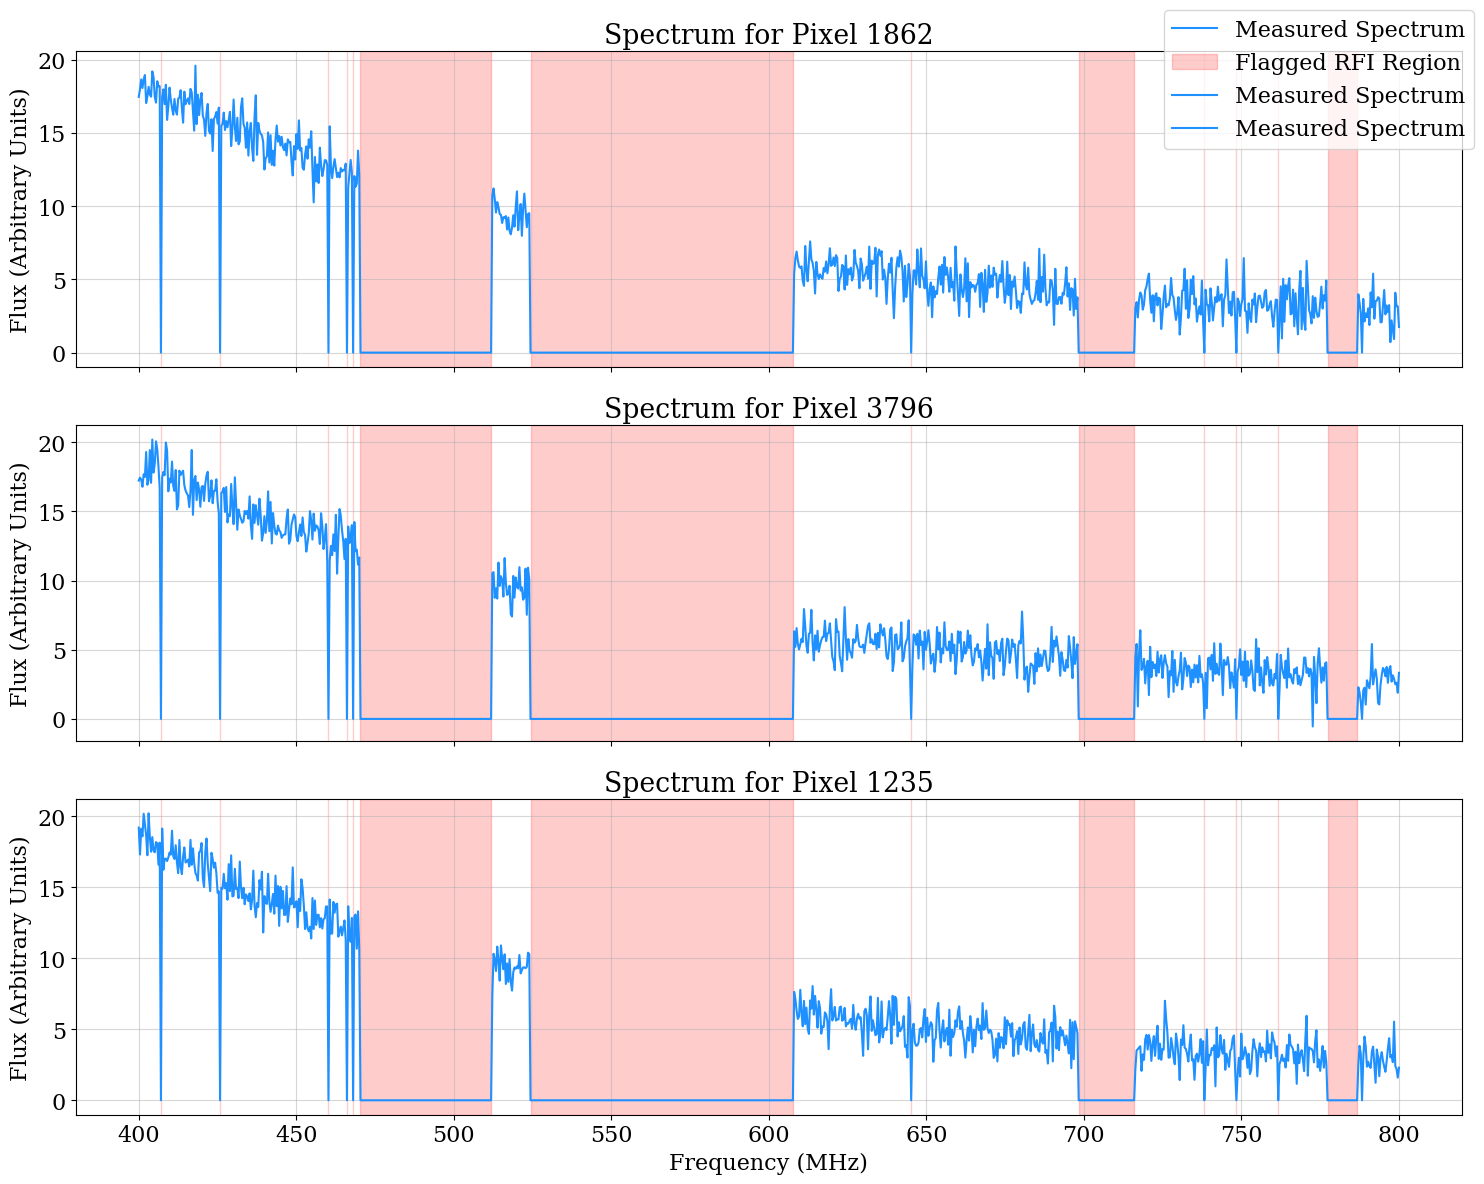

In [37]:
print("--- Displaying Sample Spectra with RFI Masking ---")

# Select a few random pixels to inspect
num_to_plot = 3
pixel_indices_to_plot = np.random.choice(N_PIXELS, num_to_plot, replace=False)

# Create the plot
fig, axes = plt.subplots(num_to_plot, 1, figsize=(15, 4 * num_to_plot), sharex=True)
if num_to_plot == 1:
    axes = [axes] # Ensure axes is always iterable

for i, pixel_idx in enumerate(pixel_indices_to_plot):
    ax = axes[i]
    
    # Plot the spectrum from the data cube
    ax.plot(FREQS_MHZ, data_cube[pixel_idx, :], color='dodgerblue', label='Measured Spectrum')
    
    # Highlight the flagged RFI regions in red
    # `rfi_mask_boolean` is True for GOOD channels, so we plot where it's False
    flagged_indices = np.where(~rfi_mask_boolean)[0]
    
    # To avoid plotting thousands of individual lines, we can find contiguous blocks
    for start in np.where(np.diff(flagged_indices) > 1)[0]:
        end_idx = flagged_indices[start]
        start_idx = flagged_indices[np.where(np.diff(flagged_indices) > 1)[0][np.where(np.where(np.diff(flagged_indices) > 1)[0] == start)[0][0]-1]+1] if start !=0 else flagged_indices[0]
        ax.axvspan(FREQS_MHZ[start_idx], FREQS_MHZ[end_idx], color='red', alpha=0.2, label='Flagged RFI Region' if i == 0 and start == np.where(np.diff(flagged_indices) > 1)[0][0] else "")


    ax.set_title(f'Spectrum for Pixel {pixel_idx}')
    ax.set_ylabel('Flux (Arbitrary Units)')
    ax.grid(True, alpha=0.5)

ax.set_xlabel('Frequency (MHz)')
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

--- Displaying Sample Spectra with RFI Masking and Infilling---


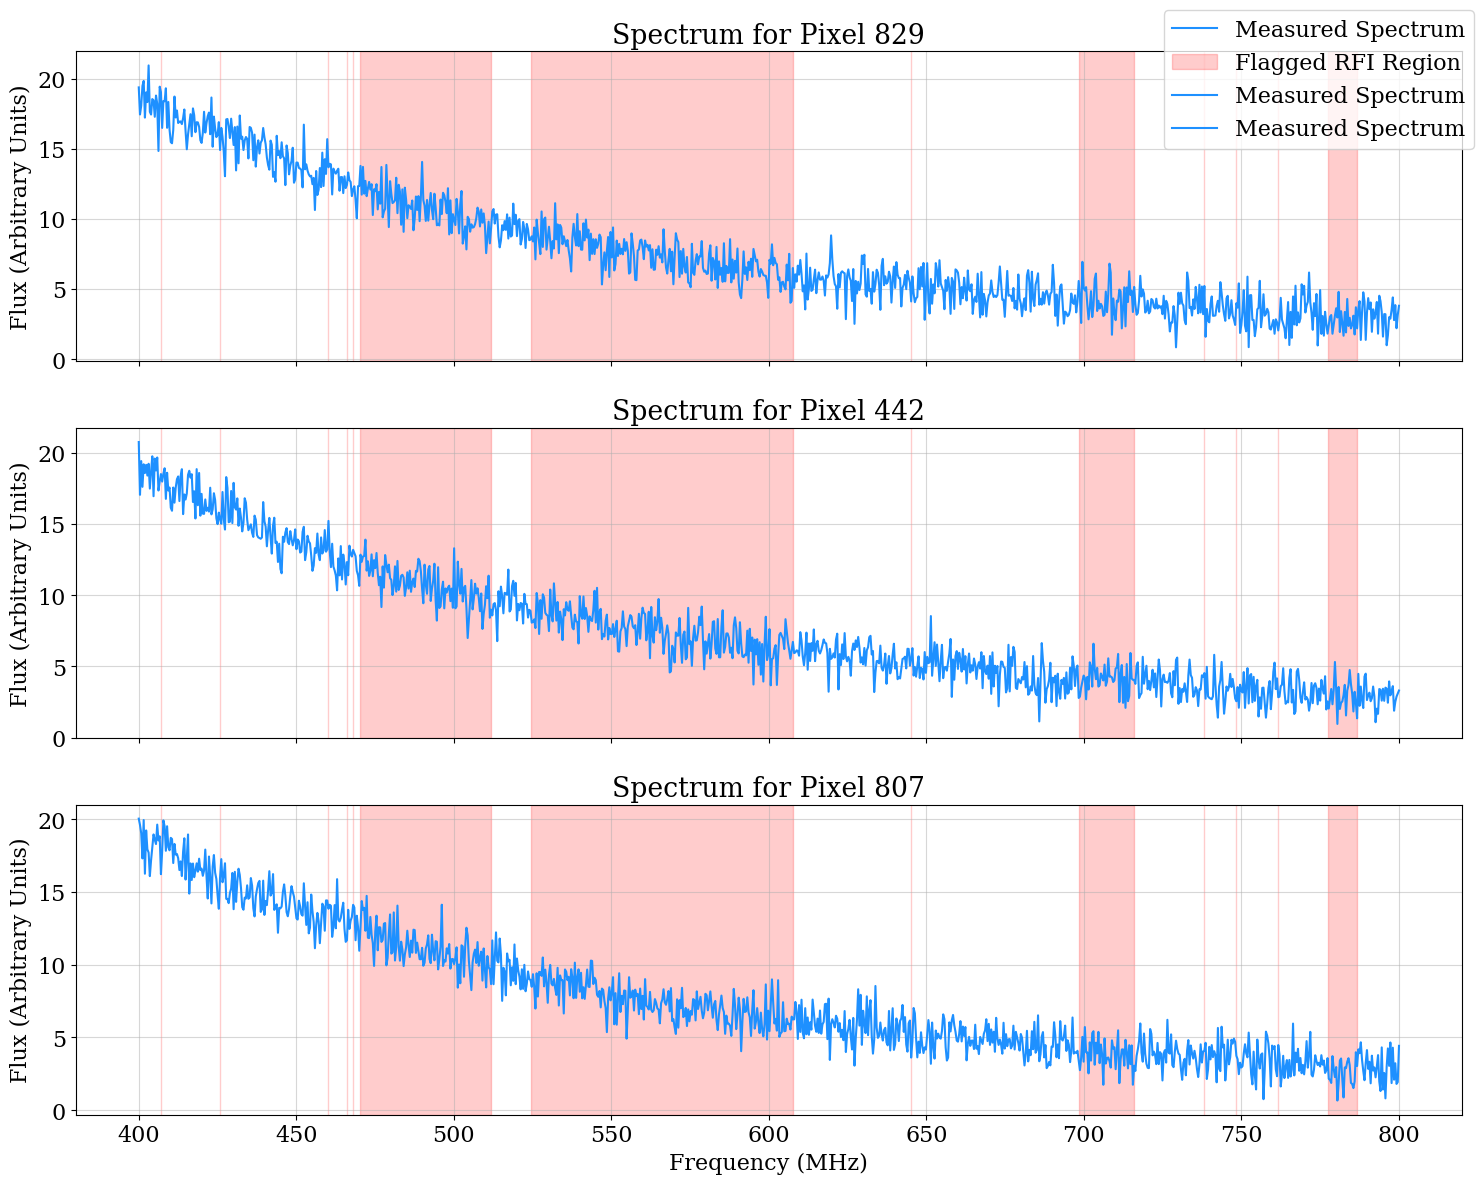

In [38]:
print("--- Displaying Sample Spectra with RFI Masking and Infilling---")

# Select a few random pixels to inspect
num_to_plot = 3
pixel_indices_to_plot = np.random.choice(N_PIXELS, num_to_plot, replace=False)

# Create the plot
fig, axes = plt.subplots(num_to_plot, 1, figsize=(15, 4 * num_to_plot), sharex=True)
if num_to_plot == 1:
    axes = [axes] # Ensure axes is always iterable

for i, pixel_idx in enumerate(pixel_indices_to_plot):
    ax = axes[i]
    
    # Plot the spectrum from the data cube
    infilled_spectrum = oss.infill_rfi(spectrum=data_cube[pixel_idx, :],frequencies=FREQS_MHZ, weights=rfi_mask_boolean)
    ax.plot(FREQS_MHZ, infilled_spectrum, color='dodgerblue', label='Measured Spectrum')
    
    # Highlight the flagged RFI regions in red
    # `rfi_mask_boolean` is True for GOOD channels, so we plot where it's False
    flagged_indices = np.where(~rfi_mask_boolean)[0]
    
    # To avoid plotting thousands of individual lines, we can find contiguous blocks
    for start in np.where(np.diff(flagged_indices) > 1)[0]:
        end_idx = flagged_indices[start]
        start_idx = flagged_indices[np.where(np.diff(flagged_indices) > 1)[0][np.where(np.where(np.diff(flagged_indices) > 1)[0] == start)[0][0]-1]+1] if start !=0 else flagged_indices[0]
        ax.axvspan(FREQS_MHZ[start_idx], FREQS_MHZ[end_idx], color='red', alpha=0.2, label='Flagged RFI Region' if i == 0 and start == np.where(np.diff(flagged_indices) > 1)[0][0] else "")


    ax.set_title(f'Spectrum for Pixel {pixel_idx}')
    ax.set_ylabel('Flux (Arbitrary Units)')
    ax.grid(True, alpha=0.5)

ax.set_xlabel('Frequency (MHz)')
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Scenario 3: Foreground Subtraction with a Delay Filter

The most significant contaminant in our data, even more so than instrumental noise, is the sky itself. Our galaxy and distant radio sources produce incredibly bright foreground emission that is smooth in frequency. This smooth-spectrum emission can be thousands of times brighter than the faint, narrow-band OHM signals we are searching for.

To detect our signals, we must first remove this overwhelming foreground. We can achieve this by transforming our data from the frequency domain into the **delay domain**.

#### What is Delay Space? ⏳

A Fourier transform of a frequency spectrum produces its corresponding "delay spectrum." In this delay space, a signal's properties are mapped differently:

  * **Spectrally Smooth Signals**: Bright, smooth-spectrum sources (like our foregrounds) have very little variation across frequency. In delay space, this means their power is highly concentrated at the origin, at **low delays** (near 0 ns).
  * **Spectrally Complex Signals**: Faint, narrow-band signals (like our OHM masers) have sharp, complex features in the frequency domain. In delay space, this complexity spreads their power far from the origin, out to **high delays**.

#### The Delay Filter

This separation allows us to apply a powerful filter. We perform a Fourier transform on the data, set a "notch" at the center to remove everything at low delay (the foregrounds), and then transform the data back to the frequency domain. The result is a "delay-filtered" spectrum where the bright, smooth foregrounds have been effectively subtracted, allowing the faint, high-delay maser signals to become visible. We will use a **250 ns** delay cut, which is a strong filter designed to aggressively remove foregrounds.


## UPDATE FOR DAYNEU FILTER
-----

### Applying the Delay Filter


## The Dayenu Filter: An Explanation 🧙‍♂️

The Dayenu filter is a powerful technique for separating a faint, structured signal from a bright, smooth "foreground" signal. This is the central challenge in many radio astronomy experiments.

### The Intuitive Analogy: Removing a Hum from a Recording

Imagine you're recording a podcast, but your refrigerator is making a constant, low-pitched **hum** in the background. Your voice is the complex, interesting signal you want to keep, while the refrigerator hum is the simple, uninteresting foreground you want to remove.

* **Your Voice (The Signal)**: Like an OH megamaser, your voice is "spectrally complex." It contains many different frequencies and changes rapidly. In the Fourier domain, its power is spread out.
* **The Hum (The Foreground)**: Like galactic synchrotron emission, the hum is "spectrally simple" or "smooth." It's dominated by a single low frequency. In the Fourier domain, its power is confined to a very small region.

A simple filter might just cut out all low frequencies. This would remove the hum, but it might also remove the low-frequency parts of your voice, changing its quality.

**Dayenu is like a very smart noise-cancellation filter.** Instead of just cutting out frequencies, it builds a perfect mathematical model of the refrigerator hum. It can even build this model if parts of your recording are corrupted by static (which is like RFI). It then subtracts this *exact* model of the hum from the recording, leaving your voice almost perfectly intact. This ability to precisely model and remove the smooth component without distorting the desired signal is what makes Dayenu so effective.

***

### The Formal Mathematical Description

The Dayenu filter is a specific implementation of a linear Wiener filter, tailored for foreground subtraction.

Let our observed data as a function of frequency, $d(\nu)$, be a sum of three components: the foregrounds $d_{fg}(\nu)$, the cosmological signal we want to measure $d_{s}(\nu)$, and instrumental noise $n(\nu)$.

$$d(\nu) = d_{fg}(\nu) + d_{s}(\nu) + n(\nu)$$

The fundamental assumption is that the foregrounds $d_{fg}(\nu)$ are **spectrally smooth**. This means that in the Fourier conjugate domain, known as **delay space** (with coordinates $\tau$), the foregrounds are confined to a compact region near $\tau=0$. Our desired signal $d_s(\nu)$, being spectrally complex, has power spread over a much wider range of delays.

The goal is to design a linear operator (a matrix) $\mathbf{F}$ that, when applied to our data $\mathbf{d}$, gives us the best estimate of the signal $\hat{\mathbf{d}}_{s}$.

$$\hat{\mathbf{d}}_{s} = \mathbf{F} \mathbf{d}$$

Dayenu constructs this operator by modeling the foregrounds not as a signal to be removed, but as a component of a covariance matrix. The filtering operation is expressed as solving for the "clean" data $\hat{\mathbf{d}}_{s}$ in the following equation:

$$(\mathbf{I} + \mathbf{C}_{fg}) \hat{\mathbf{d}}_{s} = \mathbf{d}$$

Here, $\mathbf{I}$ is the identity matrix and $\mathbf{C}_{fg}$ is the covariance matrix of the foregrounds. This formulation essentially asks: "What is the underlying clean signal that, when added to a realization of the foregrounds, produces our observed data?"

The filter is therefore the inverse of this operation:

$$\mathbf{F} = (\mathbf{I} + \mathbf{C}_{fg})^{-1}$$

The power of Dayenu comes from how it constructs $\mathbf{C}_{fg}$. For a single foreground component confined to a delay window centered at $\tau_c$ with half-width $\Delta\tau$ and an effective amplitude of $\alpha$, its covariance in the frequency domain is described by a sinc matrix:

$$\mathbf{C}_{fg}(\nu_i, \nu_j) = \alpha \cdot \text{sinc}(2 \Delta\tau (\nu_i - \nu_j)) e^{-2\pi i (\nu_i - \nu_j) \tau_c}$$

When we use the `dayenu_filter` function, we are implicitly building this $\mathbf{C}_{fg}$ matrix from the `delay_cutoff_ns` parameters. The code then directly computes the inverse matrix $\mathbf{F}$ and applies it to the data to recover the signal. When RFI is present, a weighting matrix $\mathbf{W}$ is included to de-weight the flagged channels, making the operation robust: $\mathbf{F} = (\mathbf{W}(\mathbf{I} + \mathbf{C}_{fg})\mathbf{W})^{-1}\mathbf{W}$.

In [39]:
# --- Applying Delay Filter with Two-Pass Robust Noise Estimation ---
# # --- User-Definable Parameters ---
MASK_BRIGHT_SOURCES = False
SIGMA_THRESHOLD = 7.0
# NEW: Define the number of channels to mask on each side of a bright source
MASKING_BANDWIDTH = 5
DELAY_CUT_NS = 200.0
# --- Pass 1: Calibration Step to Get a Stable Global Noise Estimate ---
print("--- Pass 1: Calibrating a stable global noise estimate ---")

# Identify "cold" pixels where no signals were injected
all_pixel_indices = set(range(N_PIXELS))
injection_pixel_indices = set(g['pixel_index'] for g in ground_truth['injections'])
cold_pixel_indices = list(all_pixel_indices - injection_pixel_indices)

# We'll run the full pipeline on a subset of these cold pixels
num_calibration_pixels = min(200, len(cold_pixel_indices))
calibration_pixels = np.random.choice(cold_pixel_indices, num_calibration_pixels, replace=False)

noise_std_history = []
temp_filter_cache = {} # Use a temporary cache for this pass

for i in tqdm(calibration_pixels, desc="Calibrating Noise"):
    # Run the full filtering chain on a cold pixel
    temp_infilled = oss.infill_rfi_iterative(data_cube[i, :], rfi_mask_boolean, FREQS_MHZ)
    temp_masked = oss.find_and_mask_outliers(temp_infilled, SIGMA_THRESHOLD, MASKING_BANDWIDTH)
    temp_filtered, _ = oss.apply_dayneu_filter(
        temp_masked, FREQS_MHZ, DELAY_CUT_NS, cache=temp_filter_cache
    )
    # The std dev of the final filtered noise is what we want
    noise_std_history.append(np.std(temp_filtered))

# Our stable global estimate is the median of these measurements
stable_global_noise_std = np.median(noise_std_history)
print(f"  - Stable Global Noise Sigma calibrated to be: {stable_global_noise_std:.3f}")


# --- Pass 2: Main Filtering Loop Using the Stable Global Estimate ---
print("\n--- Pass 2: Applying Dayneu Filter to Full Data Cube ---")
DELAY_CUT_NS = 200.0
delay_filtered_cube = np.zeros_like(data_cube)
foreground_model_cube = np.zeros_like(data_cube)
filter_cache = {}

for i in tqdm(range(N_PIXELS), desc=f"Applying {DELAY_CUT_NS}ns Dayenu Filter"):
    # The call to infill_rfi now includes our new, stable global_noise_sigma
    infilled_spectrum = oss.infill_rfi_iterative(
        spectrum=data_cube[i, :],
        weights=rfi_mask_boolean,
        frequencies=FREQS_MHZ,
        global_noise_sigma=stable_global_noise_std # Pass the stable estimate
    )
    
    # The rest of the logic for source masking and filtering remains the same
    spectrum_for_fg_model = infilled_spectrum
    if MASK_BRIGHT_SOURCES: # Make sure this variable is defined
        spectrum_for_fg_model = oss.find_and_mask_outliers(
            spectrum=infilled_spectrum,
            sigma_threshold=SIGMA_THRESHOLD,
            mask_bandwidth_channels=MASKING_BANDWIDTH
        )

    _, foreground_model_spectrum = oss.apply_dayneu_filter(
        spectrum=spectrum_for_fg_model,
        frequencies_mhz=FREQS_MHZ,
        delay_cutoff_ns=DELAY_CUT_NS,
        cache=filter_cache
    )
    
    final_filtered_spectrum = infilled_spectrum - foreground_model_spectrum
    delay_filtered_cube[i, :] = final_filtered_spectrum
    foreground_model_cube[i, :] = foreground_model_spectrum

print("\nDelay filtering complete.")

# --- Sanity Check ---
std_before = np.std(data_cube)
std_after = np.std(delay_filtered_cube)
print(f"\nStandard deviation before filtering: {std_before:.2f}")
print(f"Standard deviation after filtering:  {std_after:.2f}")

--- Pass 1: Calibrating a stable global noise estimate ---


Calibrating Noise:   0%|          | 0/200 [00:00<?, ?it/s]

/Users/ckm/notebooks/mp/mp/lib/python3.11/site-packages/uvtools/dspec.py:933: ComplexWarning: Casting complex values to real discards the imaginary part
  output[sample_num] = np.dot(filter_mat, sample)


  - Stable Global Noise Sigma calibrated to be: 0.906

--- Pass 2: Applying Dayneu Filter to Full Data Cube ---


Applying 200.0ns Dayenu Filter:   0%|          | 0/4096 [00:00<?, ?it/s]


Delay filtering complete.

Standard deviation before filtering: 5.46
Standard deviation after filtering:  0.91


--- Displaying Sample Spectra with RFI Masking ---


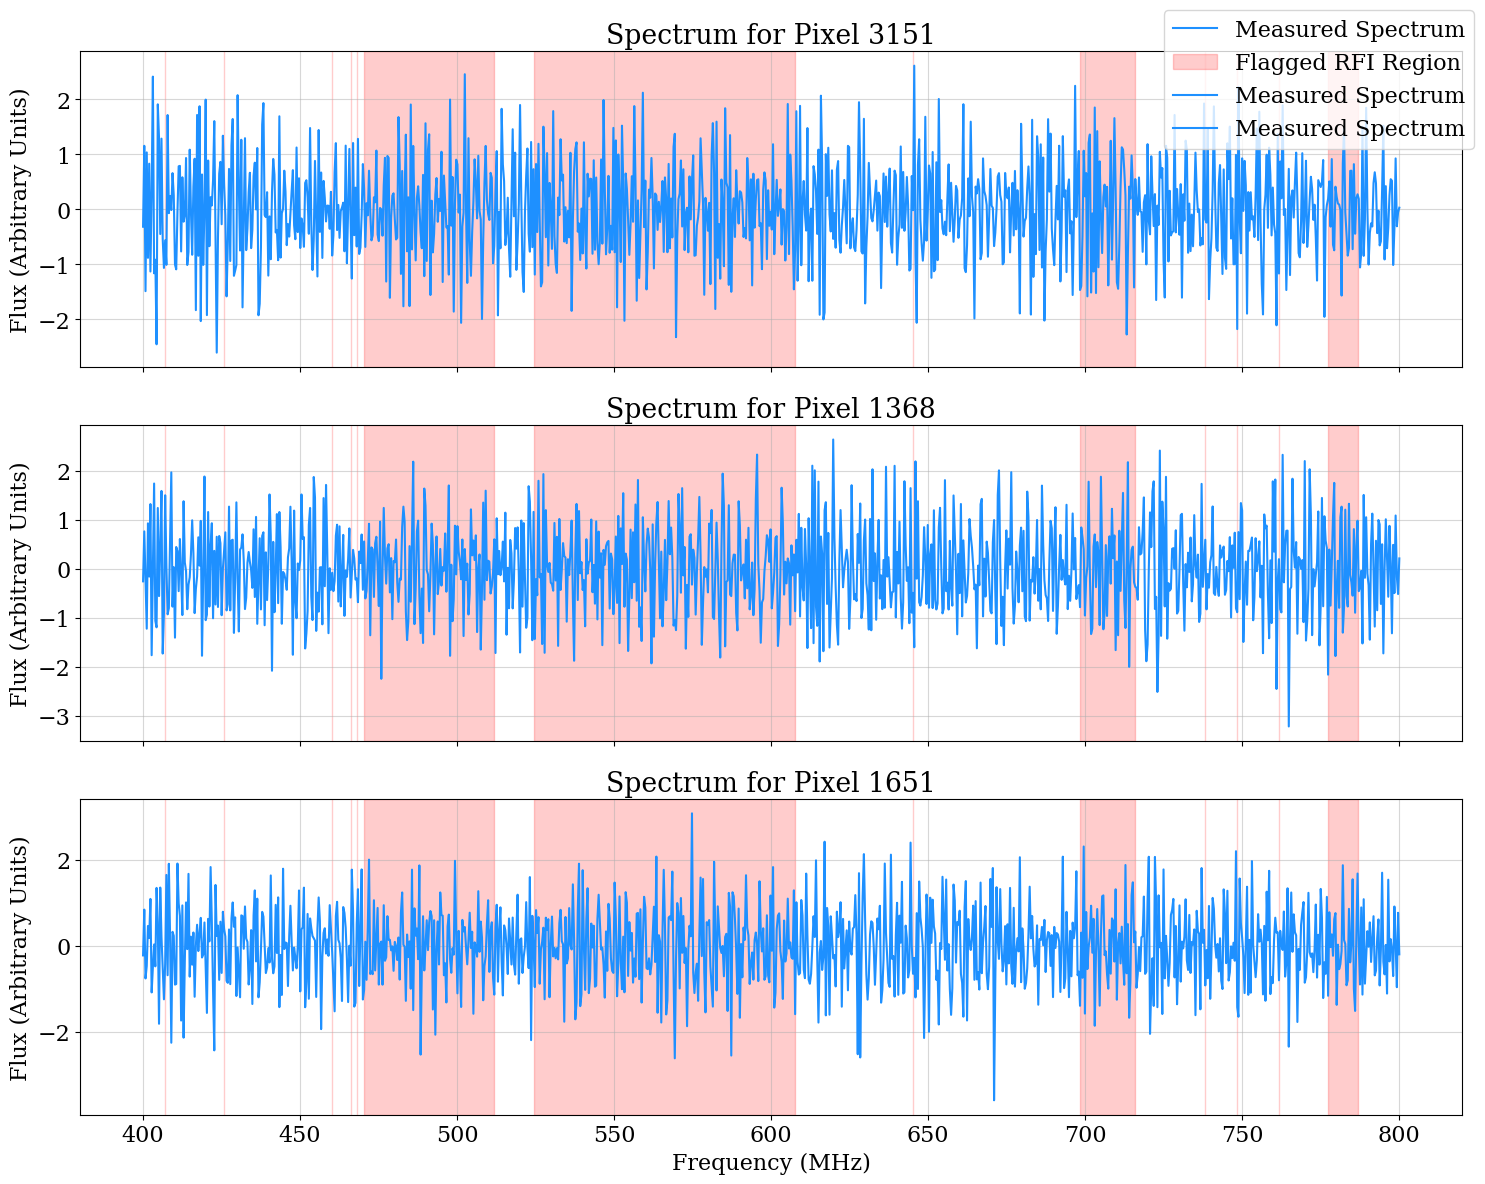

In [40]:
print("--- Displaying Sample Spectra with RFI Masking ---")

# Select a few random pixels to inspect
num_to_plot = 3
pixel_indices_to_plot = np.random.choice(N_PIXELS, num_to_plot, replace=False)

# Create the plot
fig, axes = plt.subplots(num_to_plot, 1, figsize=(15, 4 * num_to_plot), sharex=True)
if num_to_plot == 1:
    axes = [axes] # Ensure axes is always iterable

for i, pixel_idx in enumerate(pixel_indices_to_plot):
    ax = axes[i]
    
    # Plot the spectrum from the data cube
    ax.plot(FREQS_MHZ, delay_filtered_cube[pixel_idx, :], color='dodgerblue', label='Measured Spectrum')
    
    # Highlight the flagged RFI regions in red
    # `rfi_mask_boolean` is True for GOOD channels, so we plot where it's False
    flagged_indices = np.where(~rfi_mask_boolean)[0]
    
    # To avoid plotting thousands of individual lines, we can find contiguous blocks
    for start in np.where(np.diff(flagged_indices) > 1)[0]:
        end_idx = flagged_indices[start]
        start_idx = flagged_indices[np.where(np.diff(flagged_indices) > 1)[0][np.where(np.where(np.diff(flagged_indices) > 1)[0] == start)[0][0]-1]+1] if start !=0 else flagged_indices[0]
        ax.axvspan(FREQS_MHZ[start_idx], FREQS_MHZ[end_idx], color='red', alpha=0.2, label='Flagged RFI Region' if i == 0 and start == np.where(np.diff(flagged_indices) > 1)[0][0] else "")


    ax.set_title(f'Spectrum for Pixel {pixel_idx}')
    ax.set_ylabel('Flux (Arbitrary Units)')
    ax.grid(True, alpha=0.5)

ax.set_xlabel('Frequency (MHz)')
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

***

## Why Infill RFI for a Matched Filter? The Need for Speed ⚡

You might ask: "If the Dayenu filter is so robust to RFI-flagged gaps, why bother infilling them at all?"

The answer comes down to a trade-off between **robustness** and **computational speed**, especially when performing a blind search with a matched filter. While Dayenu is robust, it can be computationally intensive. For the subsequent matched filter search, we can gain a massive speed-up by using the Fast Fourier Transform (FFT), but the FFT has one critical weakness: it requires complete, uninterrupted data.

### The Convolution Theorem: A Mathematical Shortcut

A matched filter is mathematically a **cross-correlation**. A blind search involves correlating a template, $t(\nu)$, across your entire spectrum, $d(\nu)$. In the frequency domain, this is a slow, "direct summation" operation that scales poorly for large datasets, approximately as $\mathcal{O}(N^2)$.

However, a beautiful mathematical property called the **Convolution Theorem** provides a much faster path. It states that a cross-correlation in the frequency domain is equivalent to a simple element-wise multiplication in the Fourier (delay) domain.

$$(d \star t)(\tau) \Longleftrightarrow \mathcal{F}\{d\}^* \cdot \mathcal{F}\{t\}$$

Here, $\star$ is the cross-correlation, $\mathcal{F}$ is the Fourier Transform, and the asterisk ($^*$) denotes the complex conjugate.

By using the Fast Fourier Transform (FFT) algorithm, which scales as $\mathcal{O}(N \log N)$, we can perform the entire matched filter search dramatically faster. The process becomes:
1.  FFT the data and the template.
2.  Perform one simple multiplication.
3.  Inverse FFT the result to get the full SNR spectrum.

This is the method used by `run_matched_filter_fft`. But to use the FFT, the input arrays must be complete. **This is where infilling becomes essential.** By replacing the RFI-flagged gaps with plausible data, we create a complete array that unlocks the speed of the FFT for our matched filter search.

### A Historical Tidbit: The Secret History of the FFT 📜

The modern FFT algorithm, which sparked the digital signal processing revolution, is most famously credited to **James Cooley** and **John Tukey** from their 1965 paper. It was a groundbreaking development that made digital analysis of signals practical for the first time.

However, the core mathematical idea is much older! The brilliant mathematician **Carl Friedrich Gauss** actually developed a very similar method around **1805**—over 150 years earlier. He used it by hand to calculate the orbits of the asteroids Pallas and Juno. His work was published after his death but was largely overlooked until Cooley and Tukey's independent rediscovery.

The matched filter itself also has a fascinating origin. It was developed during **World War II** around 1943 by **Dwight O. North** at RCA Laboratories. Its purpose was to design the optimal receiver to maximize the signal-to-noise ratio for detecting faint radar echoes in the presence of random noise, a concept that is fundamental to signal detection theory to this day.

-----

### Interactive Viewer: Before and After Delay Filtering

To build intuition for how our foreground filter works, this interactive plot allows you to compare spectra from the same pixel side-by-side.

  * **The Left Panel** shows the raw spectrum from the GDSM simulation, including the bright, smooth foreground component.
  * **The Right Panel** shows the same spectrum *after* the **250 ns** delay filter has been applied.

Notice how the large-scale, smooth structure is removed, leaving behind what is essentially flat, Gaussian-like noise. The standard deviation ($\\sigma$) of the flux, printed in the corner of each plot, provides a quantitative measure of this effect. The goal of the filter is to dramatically reduce the standard deviation of the data before we search for faint signals.

Use the slider to explore different pixels in the simulated sky.

-----


In [41]:
from ipywidgets import interact, IntSlider
import warnings

# Suppress minor warnings from matplotlib to keep the output clean
warnings.filterwarnings("ignore", category=UserWarning)

def plot_spectral_comparison(pixel_index):
    """
    An interactive plotting function to compare a spectrum before and
    after delay filtering for a given pixel.
    """
    # Create a figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    fig.suptitle(f'Spectral Comparison for Pixel {pixel_index}', fontsize=16)

    # --- 1. Before Filtering ---
    spec_before = data_cube[pixel_index, :]
    std_before = np.std(spec_before[spec_before != 0]) # Exclude RFI-masked zeros
    ax1.plot(FREQS_MHZ, spec_before, color='firebrick', label='Before Filter')
    ax1.set_title('Before Filtering (Raw GDSM + Noise)')
    ax1.set_xlabel('Frequency (MHz)')
    ax1.set_ylabel('Flux (Arbitrary Units)')
    ax1.grid(True, alpha=0.5)
    # Display the standard deviation in the top-left corner
    ax1.text(0.02, 0.95, f'σ = {std_before:.2f}', transform=ax1.transAxes, 
             ha='left', va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.8))

    # --- 2. After Filtering ---
    spec_after = delay_filtered_cube[pixel_index, :]
    std_after = np.std(spec_after[spec_after != 0]) # Exclude RFI-masked zeros
    ax2.plot(FREQS_MHZ, spec_after, color='dodgerblue', label='After Filter')
    ax2.set_title('After Filtering (Foregrounds Removed)')
    ax2.set_xlabel('Frequency (MHz)')
    ax2.grid(True, alpha=0.5)
    # Display the standard deviation in the top-left corner
    ax2.text(0.02, 0.95, f'σ = {std_after:.2f}', transform=ax2.transAxes, 
             ha='left', va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.8))

    # Overlay the RFI mask on both plots for context
    if 'rfi_mask_boolean' in globals():
        flagged_indices = np.where(~rfi_mask_boolean)[0]
        for start in np.where(np.diff(flagged_indices) > 1)[0]:
            end_idx = flagged_indices[start]
            start_idx = flagged_indices[np.where(np.diff(flagged_indices) > 1)[0][np.where(np.where(np.diff(flagged_indices) > 1)[0] == start)[0][0]-1]+1] if start !=0 else flagged_indices[0]
            ax1.axvspan(FREQS_MHZ[start_idx], FREQS_MHZ[end_idx], color='red', alpha=0.1)
            ax2.axvspan(FREQS_MHZ[start_idx], FREQS_MHZ[end_idx], color='red', alpha=0.1)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# --- Create the Interactive Slider ---
interact(
    plot_spectral_comparison,
    pixel_index=IntSlider(min=0, max=N_PIXELS - 1, step=1, value=0, description='Pixel Index:')
);

interactive(children=(IntSlider(value=0, description='Pixel Index:', max=4095), Output()), _dom_classes=('widg…

Of course. That's an excellent idea. Visualizing the data in the image domain is just as important as viewing the spectra. This will allow you to scroll through the frequency channels and see how the spatial structure of the sky changes, especially how the bright foregrounds are removed by the delay filter.

Here are the markdown and Python cells to create this new interactive image viewer.

### Interactive Viewer: Image Slices vs. Frequency

This interactive viewer provides a different perspective on our data cube. Instead of looking at the spectrum for one pixel, we are now looking at the entire **2D sky image** at a **single frequency channel**.

  * **The Left Panel** shows the raw sky image at a specific frequency, including the GDSM foregrounds.
  * **The Right Panel** shows the same sky image *after* the delay filter has been applied.

Use the slider to scroll through the different frequency channels of the telescope. Notice how in the "Before" panel, the image is dominated by large-scale power from the foregrounds, while the "After" panel shows what is effectively a map of the instrumental noise. This viewer also tells you if the channel you are currently viewing is flagged for RFI.

-----

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import cmocean
import warnings

# Suppress minor warnings from matplotlib to keep the output clean
warnings.filterwarnings("ignore", category=UserWarning)

def plot_image_comparison(frequency_index):
    """
    An interactive plotting function to compare a 2D sky image before and
    after delay filtering for a given frequency channel.
    """
    # Create a figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Determine the frequency and RFI status for the title
    freq_mhz = FREQS_MHZ[frequency_index]
    is_flagged = not rfi_mask_boolean[frequency_index]
    rfi_status_str = "FLAGGED FOR RFI" if is_flagged else "Clean"
    
    fig.suptitle(f'Sky Image at {freq_mhz:.2f} MHz (Channel {frequency_index}) | Status: {rfi_status_str}', 
                 fontsize=16, color='red' if is_flagged else 'black')

    # --- 1. Before Filtering ---
    # Get the image slice for this frequency and reshape it to our 2D grid
    img_before = data_cube[:, frequency_index].reshape(GRID_SHAPE)
    im1 = ax1.imshow(img_before, cmap=cmocean.cm.thermal, origin='lower', aspect='auto')
    ax1.set_title('Before Filtering (Raw GDSM + Noise)')
    ax1.set_xlabel('Pixel X-coordinate')
    ax1.set_ylabel('Pixel Y-coordinate')
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label='Flux')

    # --- 2. After Filtering ---
    img_after = delay_filtered_cube[:, frequency_index].reshape(GRID_SHAPE)
    # Use the same color scale for a fair comparison
    im2 = ax2.imshow(img_after, cmap=cmocean.cm.thermal, origin='lower', aspect='auto')#, 
                     #vmin=np.min(img_before), vmax=np.max(img_before))
    ax2.set_title('After Filtering (Foregrounds Removed)')
    ax2.set_xlabel('Pixel X-coordinate')
    ax2.set_ylabel('') # Hide y-axis label for clarity
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label='Flux')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# --- Create the Interactive Slider ---
interact(
    plot_image_comparison,
    frequency_index=IntSlider(min=0, max=len(FREQS_MHZ) - 1, step=1, value=len(FREQS_MHZ)//2, description='Frequency Channel:')
);

interactive(children=(IntSlider(value=512, description='Frequency Channel:', max=1023), Output()), _dom_classe…

## Part 4: Matched Filtering and SNR Cube Generation

This is the core of the search pipeline. We apply a matched filter to our simulated data cube. The matched filter correlates the data with a set of pre-computed templates that model the expected signal shape at different redshifts.

The output is a 3D Signal-to-Noise (SNR) cube of the same dimensions as the data cube. Each voxel in this cube represents the SNR of the best-matching template at that specific sky position and frequency.

Of course! Here is a detailed markdown cell explaining the matched filter algorithm and the SNR boost calculation, complete with LaTeX equations.

***
### The Direct-Match, Multi-Template Matched Filter

Our pipeline employs a specialized matched filter designed for both efficiency and precision. Unlike a traditional approach that slides every template across the entire frequency spectrum (a full cross-correlation), our **direct-match** method tests each template only at its specific, corresponding frequency location. This provides a massive speed advantage while maintaining the core benefits of matched filtering.

The process can be broken down into four main steps:

---
#### Step 1: Building the Template Bank 🏦

The foundation of the search is a bank of realistic OHM signal templates. To avoid redundant calculations, we use a "generate once, transform many" approach:

1.  **Master Template Creation**: A single, high-resolution "master" template, $T_{\text{intrinsic}}(v)$, is generated in velocity space. This captures the intrinsic, double-peaked profile of a typical OHM signal.

2.  **Redshift Transformation**: This master template is then transformed to create a unique template for each redshift, $z$, in our search grid. This transformation maps the velocity profile to the observed frequency grid, $f_{\text{native}}$, accounting for the cosmological redshift:

    $T_z(f_{\text{native}}) = \text{transform}(T_{\text{intrinsic}}(v), z, f_{\text{native}})$

---
#### Step 2: The Direct-Match Search Algorithm 🎯

For each pixel in the sky, we take its measured frequency spectrum, $D(f)$, and test it against every template, $T_z$, in our bank. The core of the matched filter is the calculation of the Signal-to-Noise Ratio (SNR) for each template at its specific location. This is calculated as a normalized **inner product** (or dot product).

For a given template, $T_z$, which spans a specific range of frequency channels, the SNR is given by:

$\text{SNR}_z = \frac{\sum_{i} D_i \cdot T_{z,i}}{\sigma_{\text{noise}} \sqrt{\sum_{i} T_{z,i}^2}}$

where:
- $D_i$ is the data (flux) in the $i$-th frequency channel that the template overlaps.
- $T_{z,i}$ is the value of the template in that same channel.
- $\sigma_{\text{noise}}$ is the standard deviation (RMS) of the background noise.
- The term $\sqrt{\sum_{i} T_{z,i}^2}$ is the L2-norm (or "energy") of the template, which serves to properly normalize the result.

This calculation is performed for every template in the bank.

---
#### Step 3: Constructing the SNR Cube 🧊

As we calculate the SNR for each template, we build the final 3D Signal-to-Noise cube. Our algorithm "paints" the calculated SNR value across all the frequency channels that the corresponding template occupies.

Crucially, we only update a voxel's value if the new SNR is greater than the value already stored there. This ensures that for any given position in the cube, the final value represents the SNR of the **best-matching template** that overlaps that position.

---
#### Step 4: Predicting the SNR Boost ✨

A key validation step is to predict the theoretical SNR boost a signal *should* receive from the matched filter. This prediction tells us how much a signal with a known amplitude will be amplified relative to the noise.

For a noiseless injected signal, $S$, with a peak amplitude of $A_{\text{peak}}$, its theoretical SNR after filtering is:

$\text{Predicted SNR} = \frac{\sum_{i} S_i \cdot T_{S,i}}{\sigma_{\text{noise}} \sqrt{\sum_{i} T_{S,i}^2}}$

Here, $T_{S,i}$ is the **perfectly matched template** for that signal. Since the signal itself is just a scaled version of its perfect template ($S_i = A_{\text{peak}} \cdot T_{S,i}$), the equation simplifies beautifully:

$\text{Predicted SNR} = \frac{A_{\text{peak}} \sum_{i} T_{S,i}^2}{\sigma_{\text{noise}} \sqrt{\sum_{i} T_{S,i}^2}} = \frac{A_{\text{peak}}}{\sigma_{\text{noise}}} \sqrt{\sum_{i} T_{S,i}^2}$

This elegant result shows that the expected SNR is simply the signal's intrinsic SNR ($A_{\text{peak}}/\sigma_{\text{noise}}$) multiplied by the **energy of the normalized template**. This is the value we use to calculate the "Predicted True Positives" and to create the "Theoretical SNR" histogram.


#### 1. Peak SNR (Used for Detection)

This is the method our direct-match algorithm uses to **detect** signals and construct the initial SNR cube.

* **What it is**: The Peak SNR is the **single, maximum value** of the matched filter response. In our direct-match algorithm, the calculation `(data ⋅ template) / (σ * ||template||)` at a specific location is mathematically equivalent to finding the value at the peak of a full cross-correlation. The value we "paint" into the SNR cube represents this peak response.

* **Pros**:
    * **Simple Statistics**: The noise associated with the Peak SNR is well-described by a Gaussian distribution. This makes it straightforward to predict the false positive rate, as we have done in our analysis.
    * **Efficiency**: It is computationally simple and fast to calculate, making it ideal for the initial, brute-force search across the entire dataset.

* **Cons**:
    * **Sensitivity to Noise**: It can be sensitive to a single, unusually high or low noise value within the footprint of the signal. It doesn't use all the information across the signal's profile.

The equation we use for detection is a pure **Peak SNR**:

$\text{SNR}_{\text{peak}} = \frac{\sum_{i} D_i \cdot T_{z,i}}{\sigma_{\text{noise}} \cdot ||T_z||_2}$
*(where $||T_z||_2$ is the L2-norm)*



### Matched Filter: Searching in Delay-Filtered Data

Now that the bright, smooth-spectrum foregrounds have been removed from our data cube, we can proceed with the matched filter search. However, because we have applied a linear filter (the delay filter) to our data, we must apply the **exact same filter to our templates** for the search to remain mathematically optimal.

A filter is only "matched" when the template has undergone the same processing as the signal it's trying to find. If we were to use our original, unfiltered templates to search the new, delay-filtered data, there would be a significant mismatch, and the filter's performance would be severely degraded.

The process is therefore:

1.  Generate a template for a given redshift.
2.  Apply the **250 ns** delay filter to this individual template.
3.  Calculate the normalization (energy) of this *new, filtered* template.
4.  Add the filtered template to the bank.

We then use this bank of filtered templates to search our `delay_filtered_cube`. The noise level ($\\sigma$) for the search is now calculated from this filtered cube, as it represents the true noise floor after foreground subtraction.

-----

### Matched Filter Search on Delay-Filtered Cube


In [43]:
# --- 1. Build the Filtered Template Bank ---
print("--- Building Filtered Template Bank ---")
z_grid = oss.freq_to_z(FREQS_MHZ)

# Use the new function to generate both compact and full template banks
template_bank, template_bank_full = otg.create_filtered_template_bank_dayneu(
    intrinsic_template_v=intrinsic_template_v,
    vel_axis_kms=VEL_AXIS,
    z_grid=z_grid,
    native_freq_grid=FREQS_MHZ,
    delay_cut_ns=DELAY_CUT_NS
)

print(f"\nFiltered template bank created with {len(template_bank)} templates.")

--- Building Filtered Template Bank ---


Building Dayenu-Filtered Templates:   0%|          | 0/1024 [00:00<?, ?it/s]

/Users/ckm/notebooks/mp/mp/lib/python3.11/site-packages/uvtools/dspec.py:933: ComplexWarning: Casting complex values to real discards the imaginary part
  output[sample_num] = np.dot(filter_mat, sample)



Filtered template bank created with 1024 templates.



--- Running Matched Filter on Data Cube ---
  - Estimating noise with robust MAD estimator...


Applying Matched Filter to each Frequency Bin:   0%|          | 0/4096 [00:00<?, ?it/s]


SNR cube generation complete.


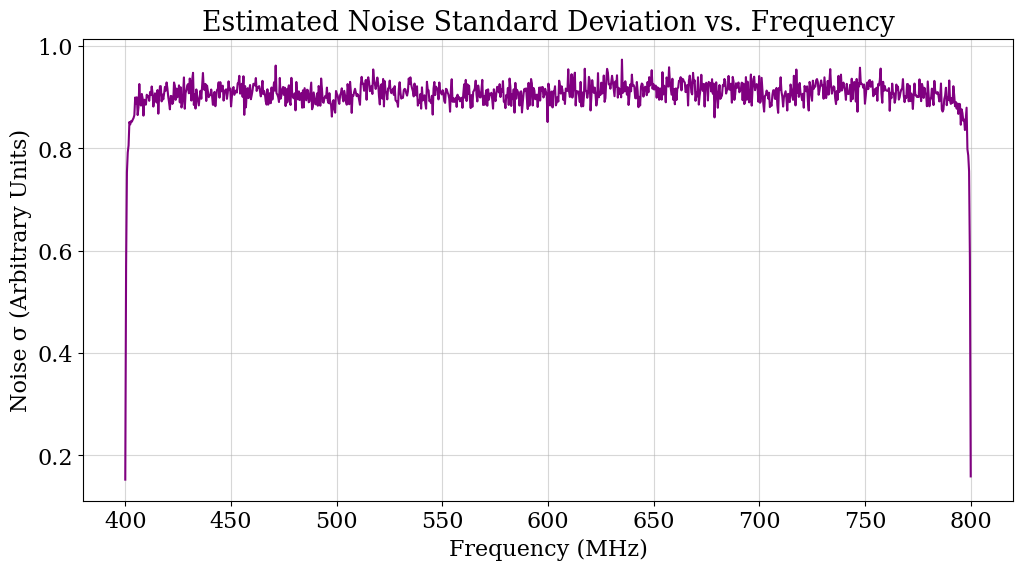

In [44]:
# --- 3. Run Matched Filter to Generate SNR Cube ---
print("\n--- Running Matched Filter on Data Cube ---")
snr_cube_3d, noise_spectrum = oss.run_matched_filter_cube(
    data_cube=delay_filtered_cube,
    template_bank_full=template_bank_full,
    weights=np.ones(len(FREQS_MHZ)) #rfi_mask_boolean, # Your RFI mask
)

print("\nSNR cube generation complete.")
# --- Sanity Check: Plot the Noise Spectrum ---
plt.figure(figsize=(12, 6))
plt.plot(FREQS_MHZ, noise_spectrum, color='purple')
plt.title('Estimated Noise Standard Deviation vs. Frequency')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Noise σ (Arbitrary Units)')
plt.grid(True, alpha=0.5)
plt.show()

## Compare Dayenu with FFT-based delay filter

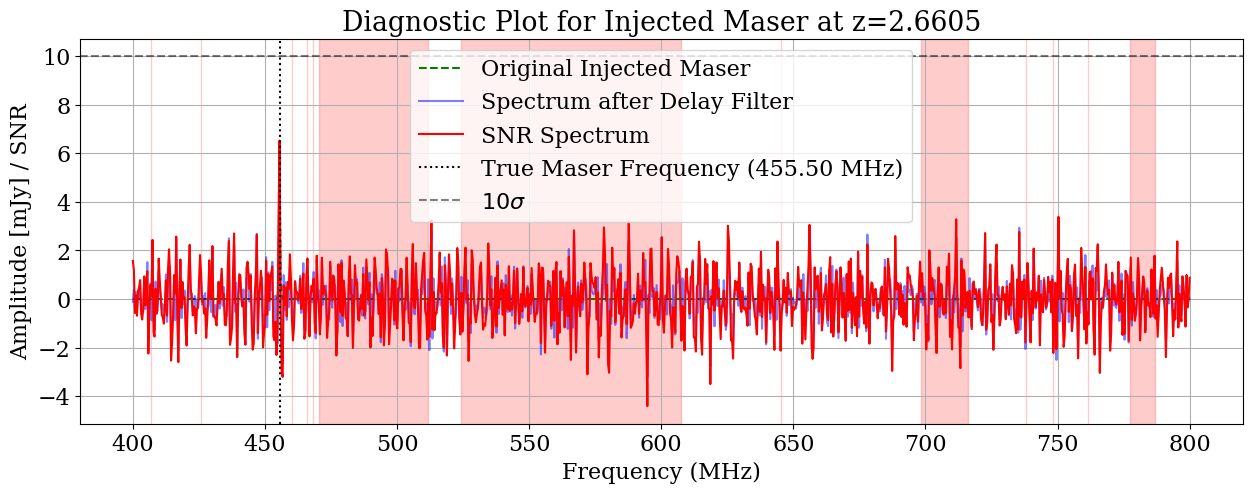

In [45]:
# Select an injected maser to inspect
injection_index = 25
pixel_idx = ground_truth['injections'][injection_index]['pixel_index']
true_z = ground_truth['injections'][injection_index]['z']
true_freq = oss.z_to_freq(true_z)

# Get the spectra
original_spectrum = ground_truth['injections'][injection_index]['noiseless_profile']
filtered_spectrum = delay_filtered_cube[pixel_idx, :]
snr_spectrum = snr_cube_3d[pixel_idx, :]

# Create the plot
plt.figure(figsize=(15, 5))
plt.plot(FREQS_MHZ, original_spectrum, label='Original Injected Maser', color='g', linestyle='--')
plt.plot(FREQS_MHZ, filtered_spectrum, label='Spectrum after Delay Filter', color='b', alpha=.5)
plt.plot(FREQS_MHZ, snr_spectrum, label='SNR Spectrum', color='r')

# Highlight the flagged RFI regions in red
# `rfi_mask_boolean` is True for GOOD channels, so we plot where it's False
flagged_indices = np.where(~rfi_mask_boolean)[0]

# To avoid plotting thousands of individual lines, we can find contiguous blocks
for start in np.where(np.diff(flagged_indices) > 1)[0]:
    end_idx = flagged_indices[start]
    start_idx = flagged_indices[np.where(np.diff(flagged_indices) > 1)[0][np.where(np.where(np.diff(flagged_indices) > 1)[0] == start)[0][0]-1]+1] if start !=0 else flagged_indices[0]
    plt.axvspan(FREQS_MHZ[start_idx], FREQS_MHZ[end_idx], color='red', alpha=0.2, label='Flagged RFI Region' if i == 0 and start == np.where(np.diff(flagged_indices) > 1)[0][0] else "")

plt.axvline(x=true_freq, color='k', linestyle=':', label=f'True Maser Frequency ({true_freq:.2f} MHz)')
plt.axhline(y=10, color='k', linestyle='dashed', alpha=.5, label=r'$10 \sigma$')
plt.title(f'Diagnostic Plot for Injected Maser at z={true_z:.4f}')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Amplitude [mJy] / SNR')
plt.legend()
plt.grid(True)
plt.show()

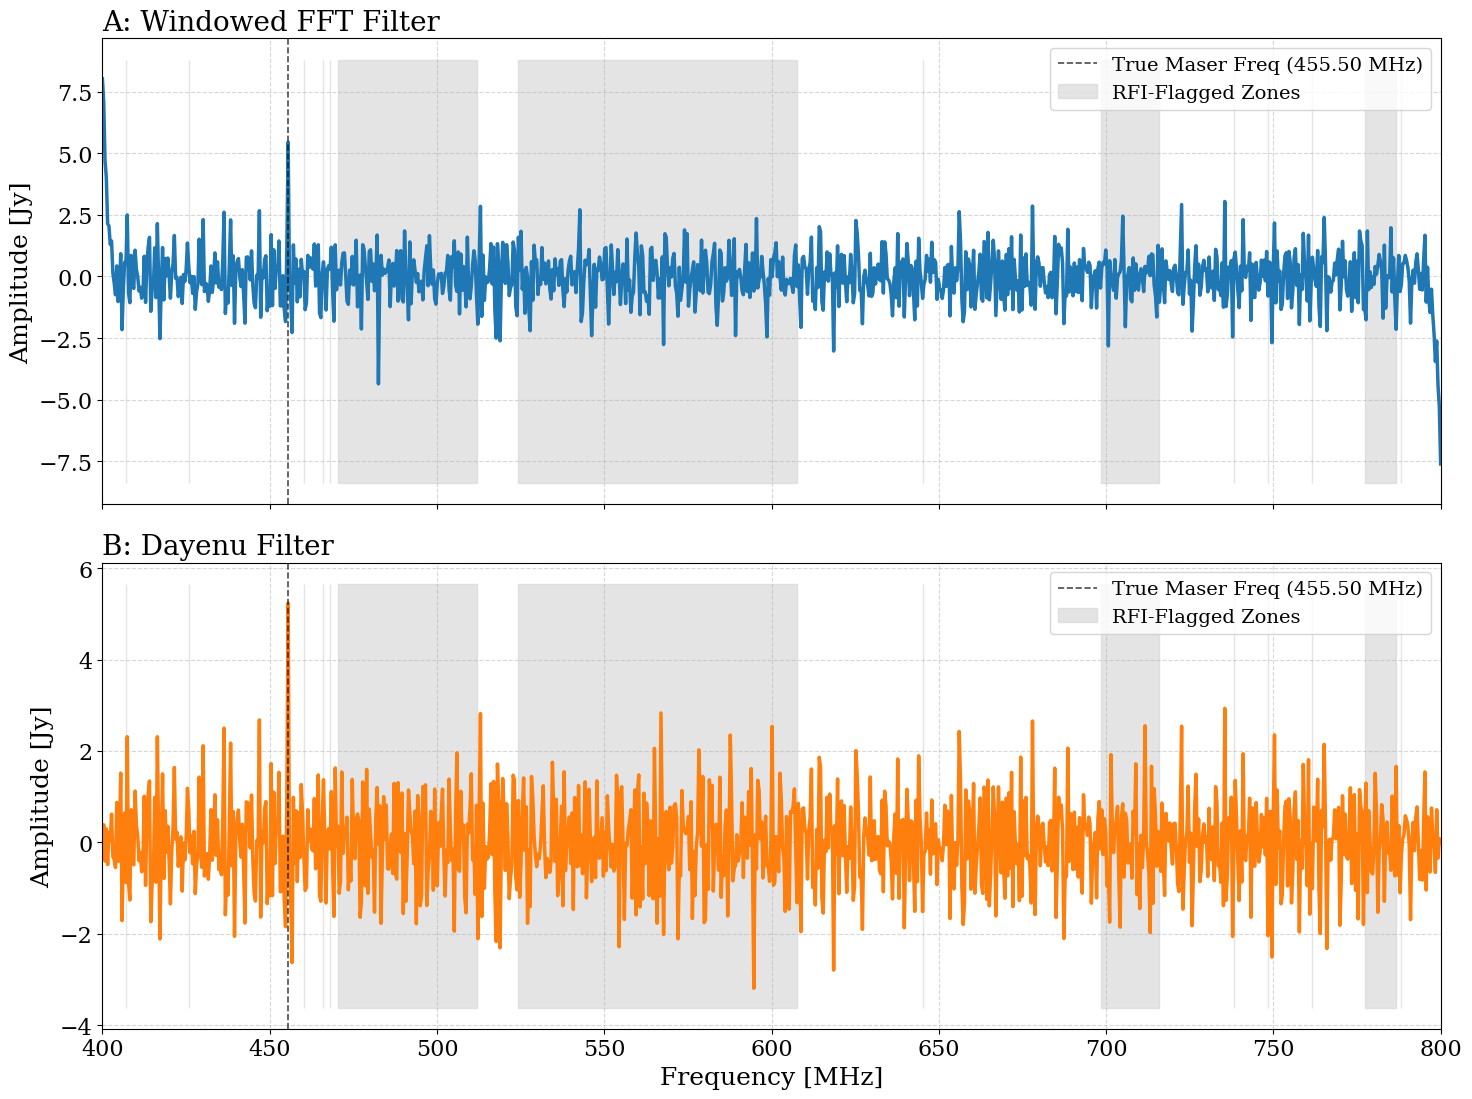

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup and Data Extraction ---
# Select a representative high-amplitude injection to plot (e.g., the first one)
injection_index = 25
g_truth = ground_truth['injections'][injection_index]
pixel_idx = g_truth['pixel_index']
true_freq = oss.z_to_freq(g_truth['z'])

spectrum_dayenu = delay_filtered_cube[pixel_idx, :]

spectrum_fft = oss.apply_windowed_delay_filter(
    spectrum=oss.infill_rfi_iterative(data_cube[pixel_idx, :], rfi_mask_boolean, FREQS_MHZ),
    weights=np.ones(N_CHANNELS), # Use uniform weights for the filter itself
    freqs_mhz=FREQS_MHZ,
    delay_cut_ns=DELAY_CUT_NS
)
    
# --- 2. Create the Figure ---
# Use a professional font and larger sizes for publication
plt.rcParams.update({'font.size': 16, 'font.family': 'serif'})
fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
# fig.suptitle("Comparison of Foreground Filter Performance on a High-Amplitude Signal", fontsize=24, y=0.96)

# --- 3. Plot Each Panel ---

# Panel A: Windowed FFT Delay Filter
axes[0].plot(FREQS_MHZ, spectrum_fft, color='C0', lw=2.5)
axes[0].set_ylabel("Amplitude [Jy]", fontsize=18)
axes[0].set_title("A: Windowed FFT Filter", loc='left', fontsize=20)


# Panel B: Dayenu Filter
axes[1].plot(FREQS_MHZ, spectrum_dayenu, color='C1', lw=2.5)
axes[1].set_xlabel("Frequency [MHz]", fontsize=18)
axes[1].set_ylabel("Amplitude [Jy]", fontsize=18)
axes[1].set_title("B: Dayenu Filter", loc='left', fontsize=20)


# --- 4. Add Enhancements to Both Panels ---
for ax in axes:
    # Add a vertical line to show the true maser frequency
    ax.axvline(true_freq, color='k', linestyle='--', lw=1.2, alpha=0.7, label=f'True Maser Freq ({true_freq:.2f} MHz)')

    # Shade the RFI-flagged regions for context
    ax.fill_between(FREQS_MHZ, ax.get_ylim()[0], ax.get_ylim()[1], where=(~rfi_mask_boolean),
                     color='lightgrey', alpha=0.6, label='RFI-Flagged Zones', step='mid')

    ax.legend(loc='upper right', fontsize=14)
    ax.grid(True, which="both", ls="--", alpha=0.5)
    # Set the x-axis to show the full CHIME band
    ax.set_xlim(FREQS_MHZ.min(), FREQS_MHZ.max())
    # Set a symmetric y-axis to emphasize ringing
    max_abs_y = np.max(np.abs(ax.get_ylim()))
    # ax.set_ylim(-max_abs_y, max_abs_y)


# --- 5. Final Touches and Display ---
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

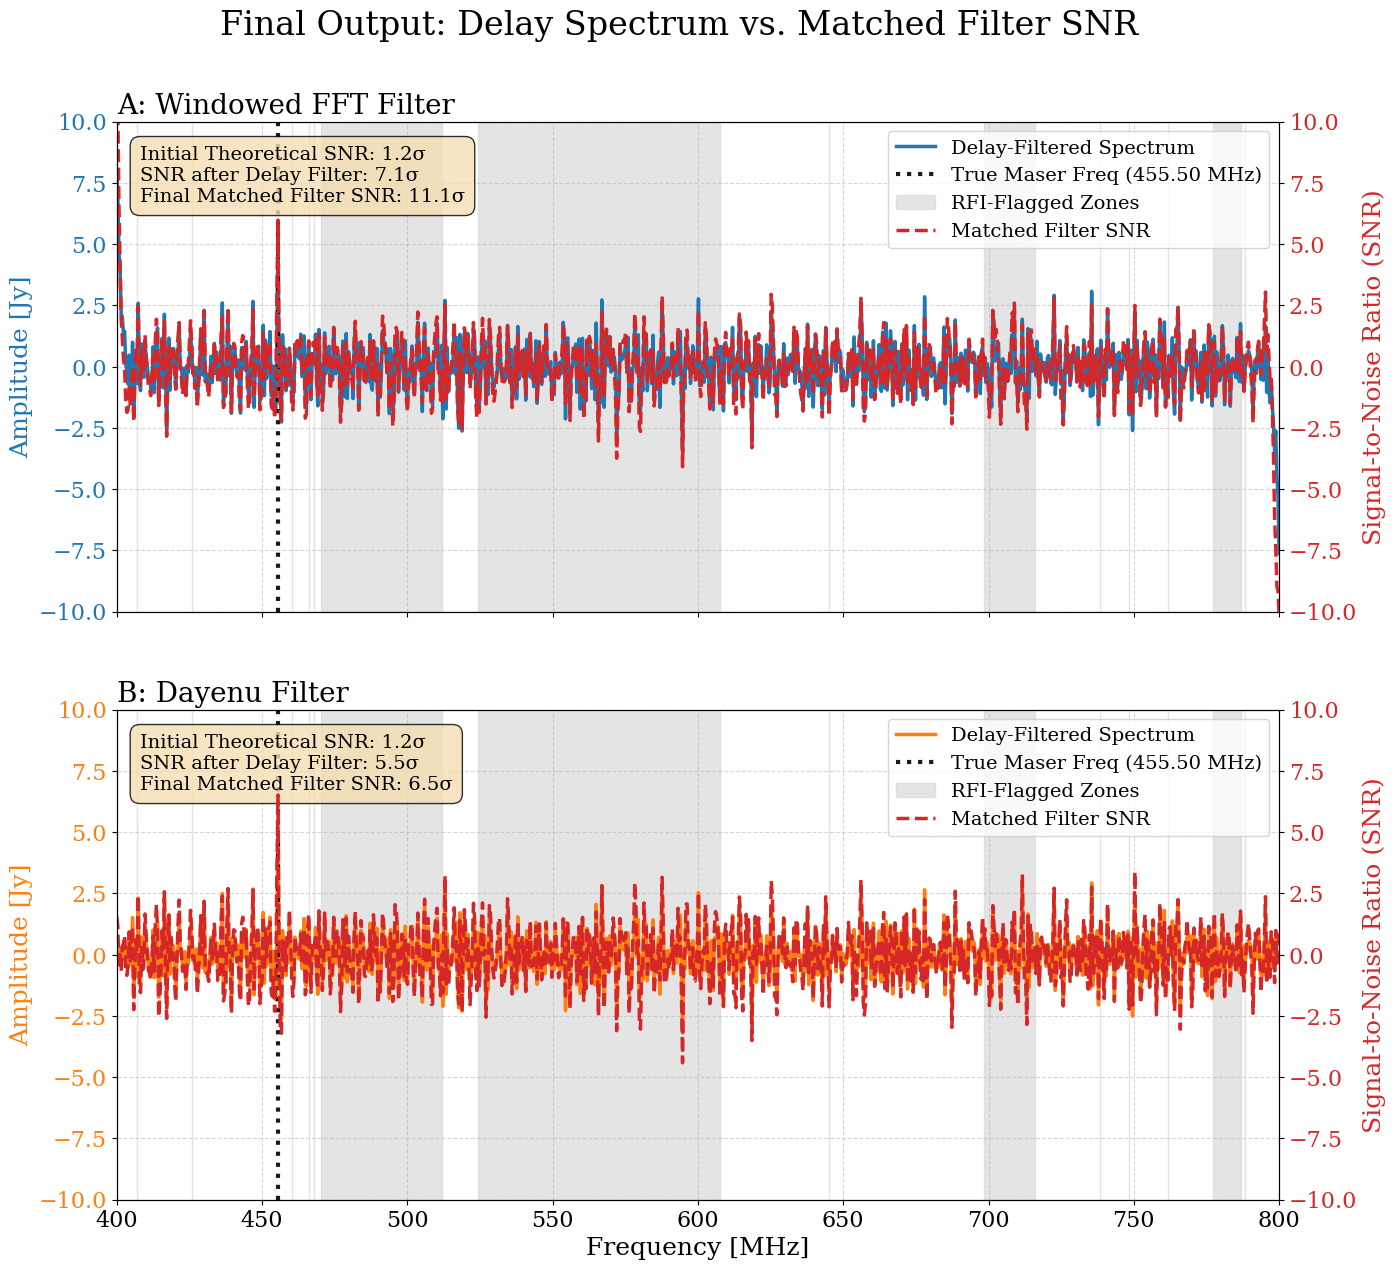

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup and Data Extraction ---
injection_index = 25
g_truth = ground_truth['injections'][injection_index]
pixel_idx = g_truth['pixel_index']
true_freq = oss.z_to_freq(g_truth['z'])
original_amplitude = g_truth['amp']
initial_snr = original_amplitude / 5

# 2. Load FFT snr cube data
delay_cube_fft = np.load('FFT_delay_cube.npy')
delay_filtered_fft = delay_cube_fft[pixel_idx, :]
snr_cube_fft = np.load('FFT_snr_cube.npy')
snr_spectrum_fft = snr_cube_fft[pixel_idx, :]

# --- Dayenu Filter Data ---
delay_filtered_dayenu = delay_filtered_cube[pixel_idx, :]
snr_spectrum_dayenu = snr_cube_3d[pixel_idx, :]

# --- 3. Calculate Intermediate SNRs for Annotations ---
snr_after_delay_fft = np.max(np.abs(delay_filtered_fft)) / np.std(delay_filtered_fft)
snr_after_delay_dayenu = np.max(np.abs(delay_filtered_dayenu)) / np.std(delay_filtered_dayenu)
final_snr_fft = np.max(snr_spectrum_fft)
final_snr_dayenu = np.max(snr_spectrum_dayenu)

# --- 4. Create the Figure ---
plt.rcParams.update({'font.size': 16, 'font.family': 'serif'})
fig, axes = plt.subplots(2, 1, figsize=(15, 14), sharex=True)
fig.suptitle("Final Output: Delay Spectrum vs. Matched Filter SNR", fontsize=24, y=0.96)

# --- 5. Plot Each Panel with Independent Twin Axes ---

# --- Panel A: Windowed FFT Filter ---
ax1 = axes[0]
ax1_snr = ax1.twinx()

# Plot amplitude data (UNCOMMENTED)
ax1.set_ylim(-10,10)
ax1.plot(FREQS_MHZ, delay_filtered_fft, color='C0', lw=2.5, label='Delay-Filtered Spectrum')
ax1.set_ylabel("Amplitude [Jy]", fontsize=18, color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.set_title("A: Windowed FFT Filter", loc='left', fontsize=20)

ax1_snr.set_ylim(-10,10)
ax1_snr.plot(FREQS_MHZ, snr_spectrum_fft, color='C3', lw=2.5, linestyle='--', label='Matched Filter SNR')
ax1_snr.set_ylabel("Signal-to-Noise Ratio (SNR)", fontsize=18, color='C3')
ax1_snr.tick_params(axis='y', labelcolor='C3')

fft_text = (f"Initial Theoretical SNR: {initial_snr:.1f}σ\n"
            f"SNR after Delay Filter: {snr_after_delay_fft:.1f}σ\n"
            f"Final Matched Filter SNR: {final_snr_fft:.1f}σ")
ax1.text(0.02, 0.95, fft_text, transform=ax1.transAxes, ha='left', va='top', fontsize=14,
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.8))

# --- Panel B: Dayenu Filter ---
ax2 = axes[1]
ax2_snr = ax2.twinx()

ax2.set_ylim(-10,10)
ax2.plot(FREQS_MHZ, delay_filtered_dayenu, color='C1', lw=2.5, label='Delay-Filtered Spectrum')
ax2.set_xlabel("Frequency [MHz]", fontsize=18)
ax2.set_ylabel("Amplitude [Jy]", fontsize=18, color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
ax2.set_title("B: Dayenu Filter", loc='left', fontsize=20)

ax2_snr.set_ylim(-10,10)
ax2_snr.plot(FREQS_MHZ, snr_spectrum_dayenu, color='C3', lw=2.5, linestyle='--', label='Matched Filter SNR')
ax2_snr.set_ylabel("Signal-to-Noise Ratio (SNR)", fontsize=18, color='C3')
ax2_snr.tick_params(axis='y', labelcolor='C3')

dayenu_text = (f"Initial Theoretical SNR: {initial_snr:.1f}σ\n"
               f"SNR after Delay Filter: {snr_after_delay_dayenu:.1f}σ\n"
               f"Final Matched Filter SNR: {final_snr_dayenu:.1f}σ")
ax2.text(0.02, 0.95, dayenu_text, transform=ax2.transAxes, ha='left', va='top', fontsize=14,
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.8))

# --- 6. Add Common Enhancements to Both Panels ---
for ax, ax_snr in [(ax1, ax1_snr), (ax2, ax2_snr)]:
    # Get appropriate y-limits for fill_between
    y_min, y_max = ax.get_ylim()
    
    ax.axvline(true_freq, color='k', linestyle=':', lw=3, alpha=0.9, label=f'True Maser Freq ({true_freq:.2f} MHz)')
    ax.fill_between(FREQS_MHZ, y_min, y_max, where=(~rfi_mask_boolean),
                     color='lightgrey', alpha=0.6, label='RFI-Flagged Zones', step='mid')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.set_xlim(FREQS_MHZ.min(), FREQS_MHZ.max())
    
    # Combine legends properly without creating extra axes
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax_snr.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='upper right', fontsize=14)

## Part 5: 3D Candidate Finding with DBSCAN

With the SNR cube generated, we now identify significant signal candidates. Instead of simply taking the maximum SNR value in each pixel (a 2D approach), we use the **3D DBSCAN clustering algorithm**. This method treats the SNR cube as a 3D space and groups together neighboring voxels that are all above a certain SNR threshold.

This approach is more robust because:
* It is less susceptible to single-pixel noise spikes.
* It can distinguish between multiple sources at the same sky position but at different frequencies (redshifts).
* It provides a more accurate estimate of a candidate's centroid and extent in all three dimensions (sky position and frequency).

***
### Finding Candidates with DBSCAN: From Voxel-Space to Physical Objects

After the matched filter has produced a 3D Signal-to-Noise Ratio (SNR) cube, the next critical step is to identify physically meaningful signal candidates within it. Simply picking out the highest SNR voxels is not robust; it's susceptible to single-channel noise spikes and doesn't group related parts of a signal together.

To solve this, we use **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise), a powerful clustering algorithm that groups together closely packed points in space. By treating our 3D SNR cube as a spatial volume, DBSCAN allows us to identify contiguous regions of high SNR, effectively turning a cloud of voxels into a list of distinct candidate objects. 🔎

The process can be broken down into three main steps:

---
#### Step 1: Thresholding the SNR Cube

First, we apply our detection threshold ($\sigma_{\text{thresh}}$, e.g., 7.0) to the SNR cube. Any voxel with an SNR below this value is discarded. This leaves us with a sparse 3D map containing only the most significant SNR peaks, which become the input for the clustering algorithm.

---
#### Step 2: Running the DBSCAN Algorithm

DBSCAN works by defining a "cluster" based on two key parameters:

* **`eps` ($\epsilon$)**: The maximum distance (in our case, measured in pixels/channels) between two points for them to be considered neighbors.
* **`min_samples`**: The minimum number of points required to form a dense core region.

The algorithm iterates through the high-SNR voxels and classifies them:

1.  **Core Points**: A voxel is a **core point** if it has at least `min_samples` neighbors (including itself) within a radius of $\epsilon$. These are the hearts of our candidate clusters.
2.  **Border Points**: A voxel is a **border point** if it is within $\epsilon$ of a core point but does not have enough neighbors to be a core point itself. These are the edges of our candidates.
3.  **Noise Points**: Any voxel that is neither a core nor a border point is classified as **noise** and discarded.

DBSCAN connects core points that are neighbors, and then attaches their border points to form the final candidate clusters.

---
#### Step 3: Vetting Candidates and Rejecting RFI

This is where the power of DBSCAN as a "vetting" tool becomes clear. The algorithm's density-based nature provides an inherent defense against common types of noise and interference that a simple peak-finding algorithm would fail to reject:

* **Isolated Noise Spikes**: A random, single-channel noise fluctuation that happens to cross our SNR threshold will likely be isolated. Since it won't have `min_samples` neighbors, DBSCAN will correctly classify it as a **noise point** and discard it.

* **Broadband RFI**: Radio Frequency Interference (RFI) often appears as a signal that is strong across a very wide range of frequencies but is narrow in the spatial dimensions (i.e., it affects all pixels at a specific frequency). Let's say we have an RFI signal that is 1 pixel wide but 500 channels long. While it may have many high-SNR voxels, they are not clustered in a physically realistic, compact shape. By setting `eps` to a small, reasonable value (e.g., 3), DBSCAN would fail to find a dense **3D core** and would likely break this long, thin structure into many small, insignificant clusters that get discarded.

* **Instrumental Artifacts**: Other non-physical signals, like detector artifacts that might appear as lines or other strange shapes in the data cube, are also unlikely to form the kind of compact, 3D-ellipsoidal clusters that a real astrophysical signal would. DBSCAN's requirement for a dense core region makes it robust against such contaminants.

In essence, DBSCAN acts as a **morphological filter**, implicitly selecting for candidates that have the compact, 3D structure we expect from a real OH megamaser and rejecting those that are too sparse, too thin, or too oddly shaped to be astrophysical. This provides a critical layer of automated vetting before any human analysis is required.

Here is a markdown cell that explains the robust matching logic used in the updated `match_candidates_to_truth_3d` function.

***
### Matching Candidates to Ground Truth: A Robust Approach

After the pipeline finds a list of candidates, the final step in validation is to determine which of them are real detections (True Positives) and which are noise (False Positives). To do this reliably, we need a robust method for matching our found candidates to the "ground truth" list of signals we injected.

Our algorithm works by defining a 3D "matching volume" around each true injected signal and checking if a candidate's centroid falls within it.

#### The Matching Criteria

For each candidate found by DBSCAN, we compare its position to every known injected signal. A candidate is considered a successful match to an injection if its centroid satisfies two conditions simultaneously:

1.  **Spatial Proximity**: The candidate's (x, y) sky position must be within a given search radius, $R_{\text{spatial}}$, of the true signal's position. This accounts for small positional errors caused by noise.

    $d_{\text{spatial}} = \sqrt{(y_{\text{cand}} - y_{\text{inj}})^2 + (x_{\text{cand}} - x_{\text{inj}})^2} \le R_{\text{spatial}}$

2.  **Frequency Proximity**: The candidate's centroid frequency must be within a given search radius, $R_{\text{freq}}$, of the true signal's frequency. This accounts for small redshift errors, also caused by noise.

    $d_{\text{freq}} = |f_{\text{cand}} - f_{\text{inj}}| \le R_{\text{freq}}$

#### Ensuring One-to-One Matching

A critical feature of this matching algorithm is that it enforces a **one-to-one relationship**. To prevent a single bright injection from being matched to multiple nearby candidate clusters, or a single candidate being matched to multiple injections, the code keeps track of which signals and candidates have already been paired. Once a match is made, neither the candidate nor the injection is available for any further matches. This robust logic ensures that our counts of True Positives and False Positives are accurate.

Large cluster sizes are a classic symptom of what happens when you run a simple clustering algorithm on **correlated noise**. The `delay_filtered_cube` no longer contains pure, "white" Gaussian noise, and this has major consequences for DBSCAN.

### The Problem: Correlated Noise and the "Continent Effect"

Here’s what's happening:

1.  **The Delay Filter's Side Effect**: The delay filter, especially a strong one, doesn't just remove the foregrounds. It also introduces low-level, large-scale **correlations** into the background noise. You can think of it as creating very broad, faint "ripples" across the frequency spectrum of every single pixel.
2.  **The SNR Cube**: When the matched filter runs on this rippled noise, the resulting `snr_cube_3d` is also filled with these broad, low-amplitude waves.
3.  **DBSCAN's Confusion**: The DBSCAN algorithm, with its current parameters, sees these ripples. Even if the ripples are low-level (e.g., 1-2σ), there are so many connected voxels that are slightly above the noise floor that DBSCAN thinks it has found a single, enormous "continent" of signal. It then connects thousands of these voxels into one giant cluster, leading to the huge sizes you're seeing.


### Data → Delay Filter → Matched Filter → SNR Cube → DBSCAN

In [60]:
print(f"--- Finding Candidates in 3D SNR Cube (Threshold: {SNR_THRESHOLD}σ) ---")

found_candidates_3d = ocf.find_candidates_3d_dbscan(
    snr_cube=snr_cube_3d.reshape(GRID_SHAPE + (len(FREQS_MHZ),)), # Reshape to (y, x, freq)
    snr_threshold=SNR_THRESHOLD,
    eps=3,
    min_samples=1,
    freqs_mhz=FREQS_MHZ
)

print(f"Found {len(found_candidates_3d)} candidates using 3D DBSCAN.")

--- Finding Candidates in 3D SNR Cube (Threshold: 5.0σ) ---
Found 112 candidates using 3D DBSCAN.


In [61]:
# --- Candidate Vetting ---
print(f"Initial number of candidates found by DBSCAN: {len(found_candidates_3d)}")

# --- Vetting Parameters ---
# Condition 3: Define an adjustable margin for the spectral edges.
# Candidates found within this many channels of the edge will be rejected.
edge_margin_channels = 10 # set this to zero for Dayneu filter

# --- Initialize Counters for Rejected Candidates ---
rejected_band = 0
rejected_rfi = 0
rejected_edge = 0

# Create a new, vetted list of candidates
vetted_candidates = []
for cand in found_candidates_3d:
    # Get the candidate's centroid frequency
    centroid_freq = cand['centroid_z_freq']
    
    # --- Condition 1: Check if the candidate is within the observable band ---
    is_in_band = (FREQS_MHZ.min() <= centroid_freq <= FREQS_MHZ.max())
    if not is_in_band:
        rejected_band += 1
        continue # Skip to the next candidate

    # Find the index of the frequency channel closest to the centroid
    freq_idx = np.argmin(np.abs(FREQS_MHZ - centroid_freq))

    # --- Condition 2: Check if the candidate is in an RFI-flagged channel ---
    # rfi_mask_boolean is True for GOOD channels, so we check if it's True
    is_in_clean_channel = rfi_mask_boolean[freq_idx]
    if not is_in_clean_channel:
        rejected_rfi += 1
        continue # Skip to the next candidate

    # --- Condition 3: Check if the candidate is near the ends of the spectrum ---
    is_away_from_edge = (edge_margin_channels <= freq_idx < (len(FREQS_MHZ) - edge_margin_channels))
    if not is_away_from_edge:
        rejected_edge += 1
        continue # Skip to the next candidate
        
    # If the candidate passes all checks, add it to our vetted list
    vetted_candidates.append(cand)

print(f"\nNumber of candidates after vetting: {len(vetted_candidates)}")
num_rejected = len(found_candidates_3d) - len(vetted_candidates)
print(f"Total rejected candidates: {num_rejected}")
print(f"  - Rejected due to falling outside the band: {rejected_band}")
print(f"  - Rejected due to being in RFI zones: {rejected_rfi}")
print(f"  - Rejected due to being too close to spectral edges: {rejected_edge}")


# --- IMPORTANT: Overwrite the old candidate list with our new, clean one ---
found_candidates_3d = vetted_candidates

Initial number of candidates found by DBSCAN: 112

Number of candidates after vetting: 93
Total rejected candidates: 19
  - Rejected due to falling outside the band: 0
  - Rejected due to being in RFI zones: 5
  - Rejected due to being too close to spectral edges: 14


--- DBSCAN Cluster Size Report ---
Total number of candidates found: 93
Average cluster size: 1.24 voxels
Standard deviation of cluster sizes: 0.42 voxels
Minimum cluster size: 1 voxels
Maximum cluster size: 2 voxels
------------------------------------


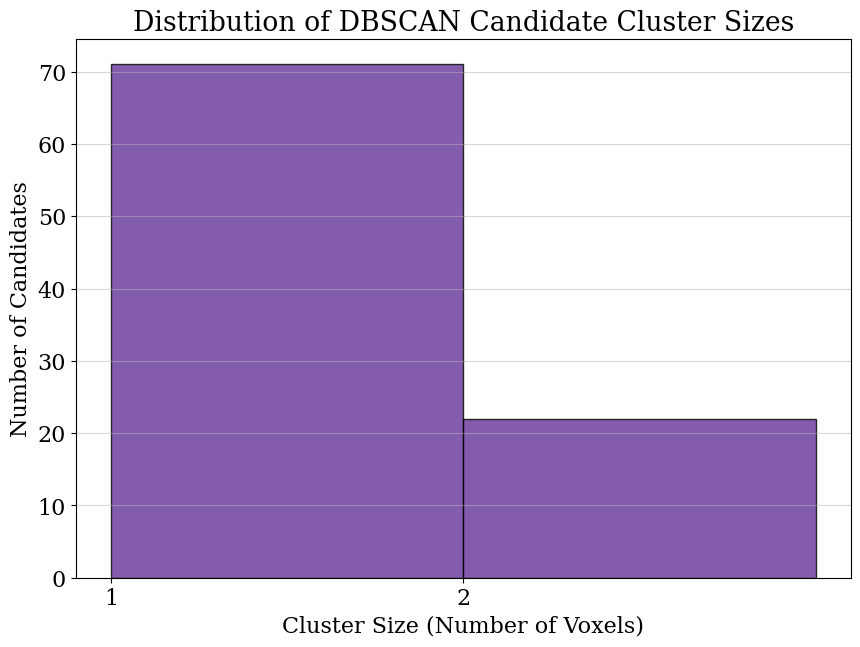

In [62]:
# --- DBSCAN Cluster Diagnostics ---

# This analysis uses the 'found_candidates_3d' list generated in Part 5
if 'found_candidates_3d' in locals() and len(found_candidates_3d) > 0:
    # Extract the size (in voxels) of each candidate cluster
    cluster_sizes = [cand['size_voxels'] for cand in found_candidates_3d]

    # --- Print Statistical Summary ---
    print("--- DBSCAN Cluster Size Report ---")
    print(f"Total number of candidates found: {len(cluster_sizes)}")
    print(f"Average cluster size: {np.mean(cluster_sizes):.2f} voxels")
    print(f"Standard deviation of cluster sizes: {np.std(cluster_sizes):.2f} voxels")
    print(f"Minimum cluster size: {np.min(cluster_sizes)} voxels")
    print(f"Maximum cluster size: {np.max(cluster_sizes)} voxels")
    print("------------------------------------")

    # --- Plot a Histogram of Cluster Sizes ---
    plt.figure(figsize=(10, 7))
    plt.hist(cluster_sizes, bins=range(min(cluster_sizes), max(cluster_sizes) + 2), 
             color='rebeccapurple', edgecolor='black', alpha=0.8)
    plt.title('Distribution of DBSCAN Candidate Cluster Sizes')
    plt.xlabel('Cluster Size (Number of Voxels)')
    plt.ylabel('Number of Candidates')
    plt.grid(True, axis='y', alpha=0.5)
    # Set x-axis ticks to be integers
    plt.xticks(np.arange(min(cluster_sizes), max(cluster_sizes)+1, step=max(1, (max(cluster_sizes)-min(cluster_sizes))//10)))
    plt.show()

else:
    print("No candidates were found, so no cluster diagnostics to report.")

***
### Vetting Candidates After Detection

The vetting process works like this:

1.  **Detection and Characterization**: The pipeline runs, and DBSCAN produces a list of candidates. For each candidate, we have a set of properties, including its **peak SNR**, its **integrated SNR**, and its **size in voxels**.
2.  **Applying Cuts**: We then apply a series of "cuts" to this list to reject non-physical candidates. This is where your example comes in. We could define a rule like:
    * `IF candidate.size_voxels > 10 THEN REJECT`
    * `IF candidate.integrated_snr / candidate.peak_snr > some_threshold THEN REJECT` (This can find oddly shaped signals)
3.  **Final Candidate List**: Only the candidates that pass all these vetting cuts are considered high-quality detections worthy of follow-up.

***


## Part 6: Performance and Validation

Now we evaluate the performance of our search by comparing the candidates found by DBSCAN against our `ground_truth` injections. This allows us to calculate key performance metrics.


-----

### Deconstructing the Search Performance Report

The search performance report provides a quantitative summary of the pipeline's effectiveness by comparing the candidates it finds to the "ground truth" of the injected signals. The report is split into two sections: **Measured Metrics**, which describe the direct results of the search, and **Validation Metrics**, which compare the results to statistical predictions.

-----

### Measured Metrics

These metrics are calculated *after* running the search and matching the found candidates to the ground truth injections.

  * **True Positives (TP)**: The number of real, injected signals that were successfully detected by the pipeline.
  * **False Positives (FP)**: The number of candidates that were incorrectly flagged as signals but correspond only to noise.
  * **False Negatives (FN)**: The number of real, injected signals that the pipeline *failed* to detect.

From these counts, we derive two key rates:

1.  **Completeness (or Recall/True Positive Rate)**: This tells us what fraction of the total real signals we actually found. A perfect pipeline has a completeness of 100%.

    $\text{Completeness} = \frac{\text{TP}}{\text{TP} + \text{FN}} = \frac{\text{Number of Signals Found}}{\text{Total Number of Injected Signals}}$

2.  **Purity (or Precision)**: This tells us what fraction of the candidates we found are actually real signals. A perfect pipeline has a purity of 100%.

    $\text{Purity} = \frac{\text{TP}}{\text{TP} + \text{FP}} = \frac{\text{Number of Real Detections}}{\text{Total Number of Detections}}$

-----

### Validation Metrics (Statistical Predictions)

These metrics are calculated from first principles to predict how the pipeline *should* behave. Comparing these predictions to the measured metrics is a critical step in validating the pipeline.

1.  **Predicted True Positives**: We calculate the theoretical Signal-to-Noise Ratio (SNR) for every single injected signal. The predicted number of true positives is simply the count of injected signals whose theoretical SNR is greater than our detection threshold ($\sigma_{thresh}$).

    $\text{Predicted TP} = \sum_{i=1}^{N_{\text{injected}}} [ \text{SNR}*{\text{theoretical}, i} \ge \sigma*{\text{thresh}} ]$
    <br>
    *(where the square brackets represent the Iverson bracket, which is 1 if the condition is true and 0 otherwise)*

2.  **Predicted False Positives**: For pure Gaussian noise, we can predict the number of noise peaks that will cross our threshold by pure chance. This is the product of the total number of independent locations we searched ($N_{\text{voxels}}$) and the probability of a single standard normal variable exceeding the threshold. This probability is given by the Gaussian survival function, often denoted $Q(x)$.

    $\text{Predicted FP} = N_{\text{voxels}} \times Q(\sigma_{\text{thresh}})$
    <br>
    where
    <br>
    $Q(x) = \frac{1}{\sqrt{2\pi}} \int_x^\infty e^{-t^2/2} dt$

3.  **Predicted Purity**: Using the two predictions above, we can calculate a theoretical purity for our search. A close match between the measured and predicted purity gives us high confidence that the matched filter and noise statistics are well-understood.

    $ \text{Predicted Purity} = \frac{\text{Predicted TP}}{\text{Predicted TP} + \text{Predicted FP}} $

-----

### Predicting Performance with RFI: A Two-Fold Approach

When Radio Frequency Interference (RFI) is present, not all signals are created equal. Some may fall into clean parts of the band, while others might be partially or completely obliterated. To account for this, we use a two-fold approach to predict our pipeline's performance.

#### 1\. The Probabilistic Estimate (The "Quick Guess") 🎲

This is a simple, first-order approximation. It assumes that the injected signals are distributed randomly across the frequency band. If a certain fraction of the band is flagged for RFI, we make a simple probabilistic guess that the same fraction of signals will be lost.

  * **Logic**: If 15% of the channels are masked by RFI, we predict a 15% loss in completeness.

  * **Equation**:

    $\text{Predicted Completeness}\_{\text{prob}} = 1 - \text{Fraction of Channels Flagged}$

This gives us a quick, back-of-the-envelope expectation for the search performance.

#### 2\. The Deterministic Prediction (The "Ground Truth" Calculation) 🔬

This is a much more precise and powerful prediction. Since we know the exact profile and frequency of every single signal we injected, we don't have to guess. We can calculate the exact impact of the RFI mask on each one.

The process is as follows:

1.  **Iterate Through Injections**: We loop through each signal in our `ground_truth` dictionary.

2.  **Calculate Energy Loss**: For each signal, we look at its `noiseless_profile` and the `rfi_mask` to determine precisely what fraction of its total energy is lost because its constituent channels were flagged.

3.  **Calculate Degraded SNR**: The signal's ideal, theoretical SNR is then degraded by this energy loss factor:

    $\text{SNR}*{\text{degraded}} = \text{SNR}*{\text{ideal}} \times \sqrt{1 - \text{Fraction of Energy Lost}}$

4.  **Count Survivors**: We then count how many of the injected signals still have a degraded SNR above our detection threshold ($\sigma\_{\text{thresh}}$).

This deterministic method gives us the **exact number of signals the pipeline should be able to find**, providing the most accurate possible prediction to validate our measured results against.

-----

### Performance Report with Advanced Predictions (Scenario 3)

In [63]:
NOISE_SIGMA_MEASURED = np.nanmean(noise_spectrum)

In [64]:
# --- Performance Report (Scenario 3) ---

# --- Match Candidates to Ground Truth ---
print("--- Matching Found Candidates to Ground Truth Injections ---")
matched_results_3d = ocf.match_candidates_to_truth_3d(
    candidates=found_candidates_3d,
    ground_truth=ground_truth,
    grid_shape=GRID_SHAPE,
    freqs_mhz=FREQS_MHZ
)

# --- Measured Metrics ---
n_tp = len(matched_results_3d['true_positives'])
n_fp = len(matched_results_3d['false_positives'])
completeness_measured = n_tp / N_INJECTIONS if N_INJECTIONS > 0 else 0
purity_measured = n_tp / len(found_candidates_3d) if found_candidates_3d else 1.0


# --- Statistical Predictions (Scenario 3) ---
print("\n--- Calculating Final Statistical Predictions ---")

# 1. PROBABILISTIC PREDICTION
# This model provides a statistical "quick guess" for comparison.
n_prob_sim = 10000
simulated_amps = np.abs(np.random.normal(loc=2, scale=3, size=n_prob_sim))
noise_sigma_measured = np.std(noise_spectrum[rfi_mask_boolean])
# A representative template energy for the quick guess
avg_template_energy = np.sum((template_bank[len(template_bank)//2]['prof'])**2)
ideal_snrs = (simulated_amps * np.sqrt(avg_template_energy)) / noise_sigma_measured
fraction_detectable_ideal = np.sum(ideal_snrs > SNR_THRESHOLD) / n_prob_sim
fraction_flagged = 1 - np.mean(rfi_weights)
# A placeholder for measured SNR loss from the filter
snr_loss_from_filter_frac = 0.01
predicted_completeness_prob = fraction_detectable_ideal * (1 - fraction_flagged) * (1 - snr_loss_from_filter_frac)
predicted_tp_prob = predicted_completeness_prob * N_INJECTIONS

# 2. DETERMINISTIC PREDICTION (End-to-End)
# This model predicts the SNR for each injection in a NOISELESS world.
predicted_peak_snrs = []
for g in tqdm(ground_truth['injections'], desc="Running End-to-End Deterministic Prediction"):
    noiseless_spectrum_original = g.get('noiseless_profile')
    if noiseless_spectrum_original is None: continue

    noiseless_spectrum_filtered, _ = oss.apply_dayneu_filter(
        spectrum=noiseless_spectrum_original,
        frequencies_mhz=FREQS_MHZ,
        delay_cutoff_ns=DELAY_CUT_NS,
        cache=filter_cache
        )
    
    theoretical_snr_spectrum = np.zeros_like(noiseless_spectrum_filtered)
    for temp_info in template_bank:
        start, end = temp_info['start'], temp_info['end']
        template_profile = temp_info['prof']
        template_mask = rfi_mask_boolean[start:end]
        template_preserved = template_profile * template_mask
        noise_segment = noise_spectrum[start:end]
        norm_effective = np.sqrt(np.sum((template_preserved / noise_segment)**2))
        if norm_effective < 1e-6: continue
        data_segment = noiseless_spectrum_filtered[start:end]
        weighted_data = data_segment / noise_segment**2
        snr = np.sum(weighted_data * template_preserved) / norm_effective
        current_snr_segment = theoretical_snr_spectrum[start:end]
        update_mask = snr > current_snr_segment
        theoretical_snr_spectrum[start:end][update_mask] = snr
        
    predicted_peak_snrs.append(np.max(theoretical_snr_spectrum))

predicted_tp_deter = np.sum(np.array(predicted_peak_snrs) > SNR_THRESHOLD)
predicted_completeness_deter = predicted_tp_deter / N_INJECTIONS if N_INJECTIONS > 0 else 0


# 3. SUPERDETERMINISTIC PREDICTION
# This is the most precise model. It measures the matched filter response on the
# final, noisy, filtered data at the exact location of each injection.
predicted_snrs_superdeter = []
for g in tqdm(ground_truth['injections'], desc="Running Superdeterministic Prediction"):
    pixel_idx = g['pixel_index']
    spectrum = delay_filtered_cube[pixel_idx, :]
    peak_snr_for_this_injection = 0.0
    
    for temp_info in template_bank:
        start, end = temp_info['start'], temp_info['end']
        template_profile = temp_info['prof']
        template_mask = rfi_mask_boolean[start:end]
        template_preserved = template_profile * template_mask
        data_segment = spectrum[start:end]
        noise_segment = noise_spectrum[start:end]
        norm_effective = np.sqrt(np.sum((template_preserved / noise_segment)**2))
        if norm_effective < 1e-6: continue
        weighted_data = data_segment / noise_segment**2
        snr = np.sum(weighted_data * template_preserved) / norm_effective
        if snr > peak_snr_for_this_injection:
            peak_snr_for_this_injection = snr
            
    predicted_snrs_superdeter.append(peak_snr_for_this_injection)

predicted_tp_superdeter = np.sum(np.array(predicted_snrs_superdeter) > SNR_THRESHOLD)
predicted_completeness_superdeter = predicted_tp_superdeter / N_INJECTIONS if N_INJECTIONS > 0 else 0

# --- REALISTIC FALSE POSITIVE PREDICTION ---

# Step 1: Count the number of channels adjacent to an RFI flag.
# np.diff on the boolean mask finds the transitions from True to False.
rfi_edges = np.diff(rfi_mask_boolean.astype(int))
num_edge_channels = np.sum(np.abs(rfi_edges))
num_edge_voxels = num_edge_channels * N_PIXELS

# Step 2: Define an empirical "fudge factor".
# This is a tunable parameter representing the increased probability of a false
# positive at an RFI edge compared to a normal Gaussian field.
# A value of 100 means we estimate edge voxels are problematic.
FP_FUDGE_FACTOR = 100
effective_fp_voxels = FP_FUDGE_FACTOR * num_edge_voxels

# Step 3: Calculate the Gaussian probability of a random peak exceeding the threshold.
# Note: This should be based on the SNR_THRESHOLD, not the noise sigma.
prob_single_fp = norm.sf(SNR_THRESHOLD) 

# Step 4: Combine these to get the final prediction.
predicted_fp_realistic = prob_single_fp * effective_fp_voxels

print(f"  - Found {num_edge_channels} RFI edge channels.")
print(f"  - Predicted False Positives (from RFI edges): {predicted_fp_realistic:.2f}")

# 4. FALSE POSITIVE & PURITY PREDICTIONS
# (This section is the same, but we add the new purity calculation)
# predicted_fp_realistic = 0 # Placeholder
predicted_purity_prob = predicted_tp_prob / (predicted_tp_prob + predicted_fp_realistic) if (predicted_tp_prob + predicted_fp_realistic) > 0 else 1.0
predicted_purity_deter = predicted_tp_deter / (predicted_tp_deter + predicted_fp_realistic) if (predicted_tp_deter + predicted_fp_realistic) > 0 else 1.0
predicted_purity_superdeter = predicted_tp_superdeter / (predicted_tp_superdeter + predicted_fp_realistic) if (predicted_tp_superdeter + predicted_fp_realistic) > 0 else 1.0


# --- FINAL REPORT (with new "Superdeterministic" column) ---
print("\n--- Search Performance Report (Scenario 3) ---")
print(f"Total Injected Signals: {N_INJECTIONS}")
print(f"Total Candidates Found: {len(found_candidates_3d)}")
print("-" * 80)
print(f"Metric         | Probabilistic | Deterministic   | Superdeterministic | Measured    |")
print(f"---------------+---------------+-----------------+--------------------+-------------|")
print(f"True Positives | {predicted_tp_prob:^13.1f} | {predicted_tp_deter:^15d} | {predicted_tp_superdeter:^18d} | {n_tp:^11d} |")
print(f"Completeness   | {predicted_completeness_prob:^13.2%} | {predicted_completeness_deter:^15.2%} | {predicted_completeness_superdeter:^18.2%} | {completeness_measured:^11.2%} |")
print(f"False Positives| {predicted_fp_realistic:^13.2f} | {predicted_fp_realistic:^15.2f} | {predicted_fp_realistic:^18.2f} | {n_fp:^11d} |")
print(f"Purity         | {predicted_purity_prob:^13.2%} | {predicted_purity_deter:^15.2%} | {predicted_purity_superdeter:^18.2%} | {purity_measured:^11.2%} |")
print("-" * 80)

--- Matching Found Candidates to Ground Truth Injections ---

--- Calculating Final Statistical Predictions ---


Running End-to-End Deterministic Prediction:   0%|          | 0/200 [00:00<?, ?it/s]

/Users/ckm/notebooks/mp/mp/lib/python3.11/site-packages/uvtools/dspec.py:933: ComplexWarning: Casting complex values to real discards the imaginary part
  output[sample_num] = np.dot(filter_mat, sample)


Running Superdeterministic Prediction:   0%|          | 0/200 [00:00<?, ?it/s]

  - Found 28 RFI edge channels.
  - Predicted False Positives (from RFI edges): 3.29

--- Search Performance Report (Scenario 3) ---
Total Injected Signals: 200
Total Candidates Found: 93
--------------------------------------------------------------------------------
Metric         | Probabilistic | Deterministic   | Superdeterministic | Measured    |
---------------+---------------+-----------------+--------------------+-------------|
True Positives |     113.5     |       84        |         86         |     86      |
Completeness   |    56.74%     |     42.00%      |       43.00%       |   43.00%    |
False Positives|     3.29      |      3.29       |        3.29        |      7      |
Purity         |    97.18%     |     96.23%      |       96.32%       |   92.47%    |
--------------------------------------------------------------------------------



***

## Comparing Prediction Models: Deterministic vs. Superdeterministic

Both of these advanced models use the same underlying **Whitened Matched Filter** formula to calculate a signal-to-noise ratio (SNR). The key difference between them is the data they are applied to.

### The Whitened Matched Filter SNR

First, let's define the core equation. For a given data spectrum $\mathbf{d}$ and a template $\mathbf{t}$, the whitened matched filter SNR is calculated as:

$$\text{SNR} = \frac{\mathbf{t}^T \mathbf{D}_n^{-1} \mathbf{d}}{\sqrt{\mathbf{t}^T \mathbf{D}_n^{-1} \mathbf{t}}}$$

Where:
* $\mathbf{d}$ is the data vector for a single spectrum.
* $\mathbf{t}$ is the template vector from the bank.
* $\mathbf{D}_n^{-1}$ is the inverse noise covariance matrix, which is assumed to be diagonal. Its diagonal elements are $1/\sigma_i^2$, where $\sigma_i$ is the noise standard deviation in the $i$-th channel.

The numerator is the dot product of the "whitened" data and template, and the denominator is the normalization factor.

---
### The Deterministic Model

This model predicts the best possible SNR for an injection in a **perfectly noiseless** universe. It answers the question: "What SNR would we measure if the only imperfections were the filter slightly changing the signal's shape and RFI flagging?"

For this model, the data vector $\mathbf{d}$ is the pure, noiseless, injected signal profile ($\mathbf{s}_{\text{true}}$) after it has been passed through the delay filter operation ($F$).

$$\mathbf{d}_{\text{det}} = F(\mathbf{s}_{\text{true}})$$

The template $\mathbf{t}$ is the best-matching template from the bank, which has also been filtered ($\mathbf{t}_{\text{filt}}$). The final SNR is therefore:

$$\text{SNR}_{\text{det}} = \frac{\mathbf{t}_{\text{filt}}^T \mathbf{D}_n^{-1} \mathbf{d}_{\text{det}}}{\sqrt{\mathbf{t}_{\text{filt}}^T \mathbf{D}_n^{-1} \mathbf{t}_{\text{filt}}}}$$

---
### The Superdeterministic Model

This is the most realistic model. It predicts the SNR by running the matched filter on the **final, noisy, filtered data slice** at the known location of an injection. It answers the question: "What was the actual SNR value in the final data cube at the signal's true location?"

For this model, the data vector $\mathbf{d}$ is the complete, final filtered spectrum, which includes the filtered foregrounds ($\mathbf{f}_{\text{filt}}$), the filtered signal ($\mathbf{s}_{\text{filt}}$), and the filtered instrumental noise ($\mathbf{n}_{\text{filt}}$).

$$\mathbf{d}_{\text{super}} = F(\mathbf{f}_{\text{true}} + \mathbf{s}_{\text{true}} + \mathbf{n}_{\text{true}}) = \mathbf{f}_{\text{filt}} + \mathbf{s}_{\text{filt}} + \mathbf{n}_{\text{filt}}$$

The template $\mathbf{t}$ is the same filtered bank template. The SNR is then calculated on this final data product:

$$\text{SNR}_{\text{super}} = \frac{\mathbf{t}_{\text{filt}}^T \mathbf{D}_n^{-1} \mathbf{d}_{\text{super}}}{\sqrt{\mathbf{t}_{\text{filt}}^T \mathbf{D}_n^{-1} \mathbf{t}_{\text{filt}}}}$$

The "Superdeterministic" prediction is the most accurate because it accounts for all effects: filter loss, RFI, instrumental noise, and even the random chance of the noise constructively or destructively interfering with the signal.

--- Displaying Sample Spectra for False Positive Candidates ---
794.5259042033235
688.9540566959922
431.28054740957964
689.3450635386118


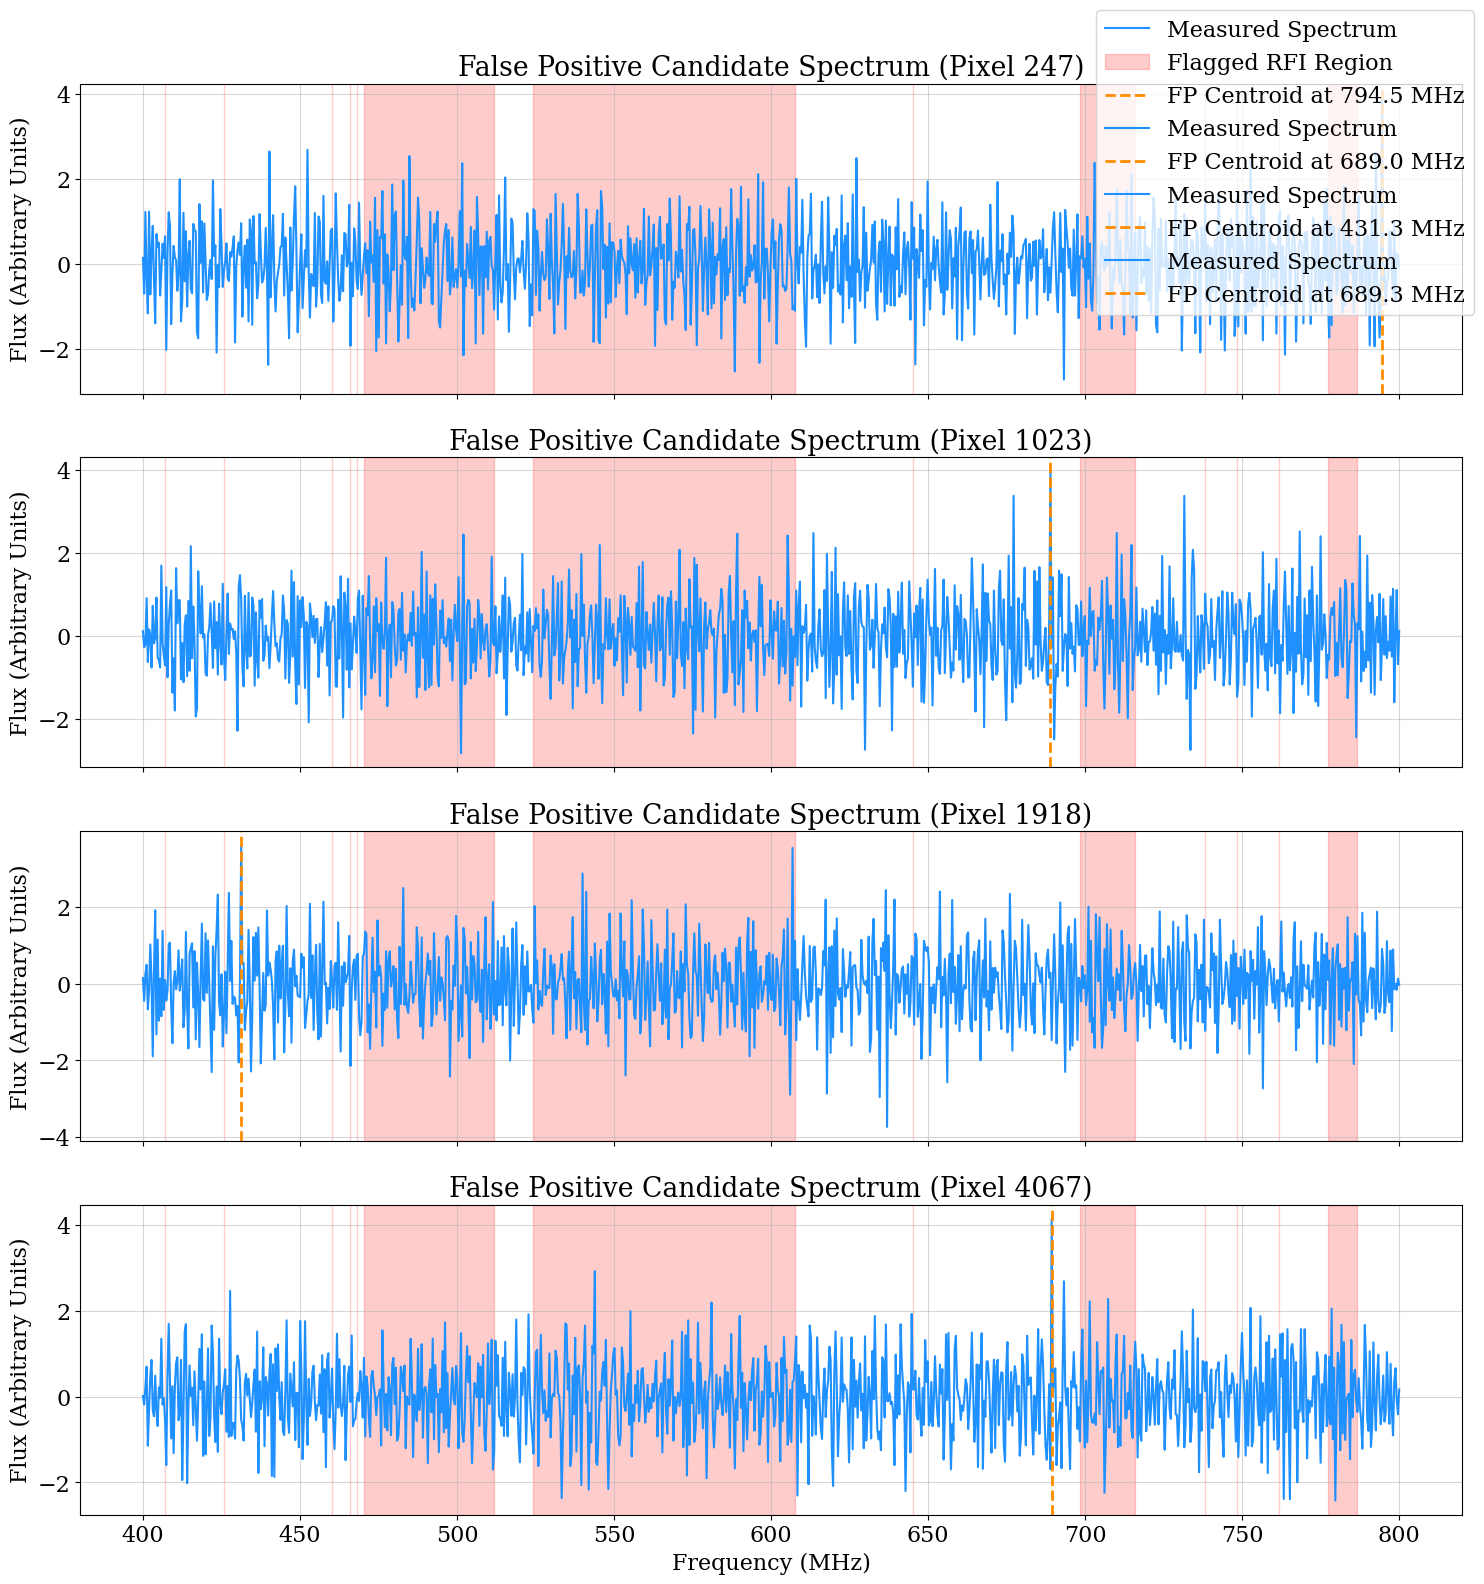

In [65]:
import numpy as np
import matplotlib.pyplot as plt

print("--- Displaying Sample Spectra for False Positive Candidates ---")

# We will use the 'false_positives' list from our matched_results_3d dictionary
if 'matched_results_3d' in locals() and len(matched_results_3d['false_positives']) > 0:
    
    # Select a few random false positives to inspect
    num_to_plot = min(4, len(matched_results_3d['false_positives']))
    fp_indices_to_plot = np.random.choice(len(matched_results_3d['false_positives']), num_to_plot, replace=False)
    
    # Create the plot
    fig, axes = plt.subplots(num_to_plot, 1, figsize=(15, 4 * num_to_plot), sharex=True, squeeze=False)
    axes = axes.flatten() # Ensure axes is always a 1D array

    for i, fp_idx in enumerate(fp_indices_to_plot):
        ax = axes[i]
        fp_cand = matched_results_3d['false_positives'][fp_idx]
        
        # --- THIS IS THE CORRECTED PART ---
        # Get the location of the false positive's centroid using the correct keys
        pixel_y = int(fp_cand['centroid_y'])
        pixel_x = int(fp_cand['centroid_x'])
        peak_freq_mhz = fp_cand['centroid_z_freq']
        pixel_1d_idx = np.ravel_multi_index((pixel_y, pixel_x), GRID_SHAPE)
        # ---------------------------------
        
        # Plot the spectrum from the data cube for this pixel
        ax.plot(FREQS_MHZ, delay_filtered_cube[pixel_1d_idx, :], color='dodgerblue', label='Measured Spectrum')
        
        # Highlight the flagged RFI regions in red
        flagged_indices = np.where(~rfi_mask_boolean)[0]
        for start in np.where(np.diff(flagged_indices) > 1)[0]:
            end_idx = flagged_indices[start]
            start_idx = flagged_indices[np.where(np.diff(flagged_indices) > 1)[0][np.where(np.where(np.diff(flagged_indices) > 1)[0] == start)[0][0]-1]+1] if start !=0 else flagged_indices[0]
            ax.axvspan(FREQS_MHZ[start_idx], FREQS_MHZ[end_idx], color='red', alpha=0.2, label='Flagged RFI Region' if i == 0 and start == np.where(np.diff(flagged_indices) > 1)[0][0] else "")

        # Mark the exact centroid of the false positive
        print(peak_freq_mhz)
        ax.axvline(peak_freq_mhz, color='darkorange', linestyle='--', lw=2, label=f'FP Centroid at {peak_freq_mhz:.1f} MHz')

        ax.set_title(f'False Positive Candidate Spectrum (Pixel {pixel_1d_idx})')
        ax.set_ylabel('Flux (Arbitrary Units)')
        ax.grid(True, alpha=0.5)

    ax.set_xlabel('Frequency (MHz)')
    fig.legend(loc='upper right')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

else:
    print("No false positives were found to plot.")

### 6.1: Diagnostic Plot 1: Candidate Overview Map

To get a visual sense of the search results, we plot a 2D map showing the maximum SNR in each pixel. On top of this, we mark the locations of the True Positives (correctly identified signals), False Positives (noise peaks mistaken for signals), and False Negatives (real signals that were missed).

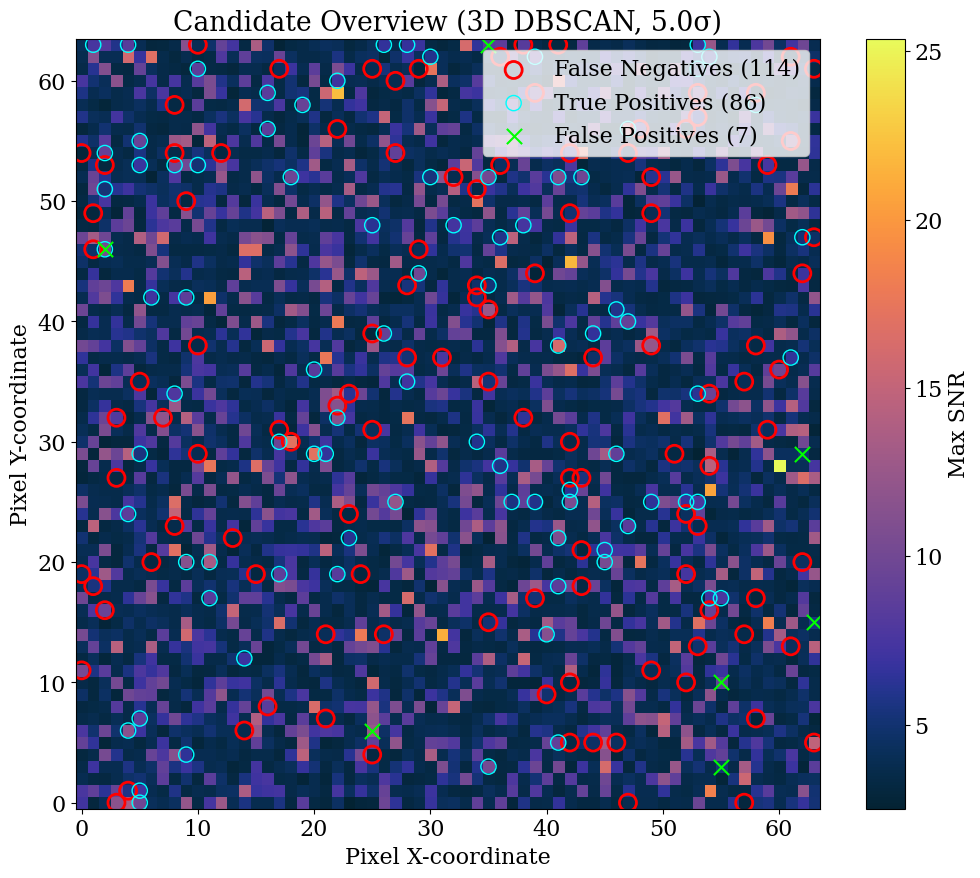

In [66]:
# For visualization, we create a 2D SNR map by taking the max along the frequency axis
snr_map_2d = np.max(snr_cube_3d, axis=1).reshape(GRID_SHAPE)

ocf.plot_performance_overview(
    snr_map=snr_map_2d,
    grid_shape=GRID_SHAPE,
    matched_results=matched_results_3d,
    title=f"Candidate Overview (3D DBSCAN, {SNR_THRESHOLD}σ)"
)

In [ ]:
### The rest of the notebook needs to be updated to be like the FFT one